In [1]:
import sys,copy,os,inspect
if hasattr(sys.modules[__name__], '__file__'):
    _file_name = __file__
else:
    _file_name = inspect.getfile(inspect.currentframe())
CURRENT_FILE_PATH = os.path.dirname(_file_name)
sys.path.append(os.getcwd()+"/../neuronVis")
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline

import IONData 
iondata = IONData.IONData()

d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
import pandas as pd

def loadClusterCSV(filename,cluster=None):
    neurons = pd.read_csv(filename)
    neuronsArray= neurons.to_numpy()
    neuronScene=[]
    for neuron in neuronsArray:
        # print(str(neuron[2])[0])
        neurondict={}
        neurondict['cluster'] = neuron[1]
        neurondict['sampleid'] = str(neuron[2])[0:6]
        neurondict['name']=str(neuron[2])[6:]+'.swc'
        property = iondata.getNeuronPropertyByID(neurondict['sampleid'], neurondict['name'])
        neurondict['soma']=property['somaregion']
        if cluster ==neuron[1] or cluster ==None:
            neuronScene.append(neurondict)
    return neuronScene

def rgbToHex(r,g,b):
    rgb = [r,g,b]
    x = ''
    for i in rgb:
      x += format(i,'02x').upper()
    if x[0] == x[1] and x[2] == x[3] and x[4] == x[5]:
      x = x[0] + x[2] + x[4]
    return '#'+x
print(rgbToHex(1,0,0))

#010000


In [3]:
import Scene
neuronScene = loadClusterCSV("../resource/cluster_eachNeuron/cluster_eachNeuron_TH.csv")
Scene.createScene(neuronScene,"../resource/TH.nv")
neuronScene = loadClusterCSV("../resource/cluster_eachNeuron/cluster_eachNeuron_spcd.csv")
Scene.createScene(neuronScene,"../resource/cluster_eachNeuron/cluster_eachNeuron_spcd.nv")
# import Visual as nv

# neuronvis = nv.neuronVis(renderModel=1)
# neuronvis.render.setBackgroundColor((0.0,0.20,0.5,1.0))
# for neuron in neuronScene[36:37]:
# 	neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
# 	neuronvis.addNeuronTree(neuronT,'200313-083.swc',somaColor=[1,0,0],axonColor=[0,1,0],dendriteColor=[0,0,1])

# neuronvis.render.run()



ModuleNotFoundError: No module named 'Scene'

In [4]:
import Scene
neuronScene = Scene.scene2List("../resource/scene/22024thneurons.nv")
print(len(neuronScene))

67


## filted TH neurons

In [30]:
import Scene
neuronScene = Scene.scene2List("../resource/scene/TH20230322.nv")
source_regions_sort_index = ['VPM','VPL','VPMpc','VPLpc','LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp']
print(len(neuronScene))
regionNeurons={}
for regions in source_regions_sort_index:
    regionNeurons[regions]=[]
for neuron in neuronScene:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    if property['somaregion'] not in source_regions_sort_index:
        print(property['somaregion'])
        continue
    else:
        regionNeurons[property['somaregion']].append(neuron)
sumNeuron=0
for region,neurons in regionNeurons.items():
    sumNeuron+=len(regionNeurons[region])
print(sumNeuron)

211
IMD
IAM
IAD
POL
PF
POL
SGN
POL
PCN
MB
MGm
PCN
PCN
AMd
IMD
IMD
PCN
PCN
PCN
IMD
PCN
PVT
PVT
IMD
LGv
186


## all TH neurons

In [5]:
import pickle
import Scene

f = open('../resource/cluster_eachNeuron/cluster_eachNeuron.pckl', 'rb')
obj = pickle.load(f)
f.close()
obj
from collections import Counter
Counter(obj["cluster_id"])
subtypes={}
# allneuronScene=[]
# for neuron in obj:
#         # print(str(neuron[2])[0])
#         neurondict={}
#         neurondict['ID'] = str(neuron)[0:6]
#         neurondict['name']=str(neuron)[6:]

#         allneuronScene.append(neurondict)
# Scene.createScene(allneuronScene,'../resource/scene/TH20221208.nv')

In [7]:
import Visual as nv
import random
neuronvis = nv.neuronVis(renderModel=1)
neuronvis.render.setBackgroundColor((1.0,1.0,1.0,1.0))
for neuron in neuronScene[:]:
	neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
	color=[random.random(),random.random(),random.random()]

	neuronvis.addNeuronTree(neuronT,'200313-083.swc',color=color)
	# break

neuronvis.render.run()

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/001.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/002.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/003.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/004.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/011.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/012.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/013.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/014.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/015.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/016.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210098/017.swc
exist  d:\project\python\neuron-

## dendrite Length

In [31]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()


# neurons = Scene.scene2List("../resource/TH.nv")
neurons = neuronScene
#target_regions = ['SSp','SSs','VISC','GU','VISp','VISam','VISpm','VISa','AUDp','AUDv','AUDd','TEa','MOp','MOs','ORBl','ORBvl','ORBm','PL','AIv','AIp','AId','ACAd','ACAv','RSPagl','RSPd']
target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT',
'STRd','STRv','LSX','sAMY','MB','HB','TH','HY','OLF','HPF','CTXsp','PAL','CB']

source_regions_sort_index = ['VPM','VPL','VPMpc','VPLpc','LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp']
source_regions_color=[[179,238,58],[0,100,0],[255,0,0],[0,0,255],[139,101,8],[205,104,57],
[255,0,255],[255,250,205],[255,20,147],[255,225,255],[207,207,207],[144,238,144],
[180,205,205],[110,123,139],[205,201,165],[238,106,167],[255,228,196],[216,191,216],
[238,154,0],[205,133,0],[205,91,69],[255,20,147],[255,52,179],[0,191,255],[150,191,200]
]
regionNeurons={}
for regions in source_regions_sort_index:
    regionNeurons[regions]=[]
for neuron in neurons:
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    if property['somaregion'] not in source_regions_sort_index:
        continue
    else:
        regionNeurons[property['somaregion']].append(neuron)
# print(regionNeurons)
propmat=[]
regionpropmat={}
for region,neuronsInRegion in regionNeurons.items():
    regionprop=[]
    propmat2=[]
    for neuron in neuronsInRegion:
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        # print(neuron)
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        if property['dendritelength']==0:
            print(neuron)
            continue
        propmat2.append(property['dendritelength'])
    if len(propmat2)>0:
        temp = np.array(propmat2)
        regionprop = temp.sum(0)
        regionpropmat[region]=temp


{'color': {'r': '151', 'g': '5', 'b': '97'}, 'name': '056.swc', 'sampleid': '211986'}
{'color': {'r': '39', 'g': '93', 'b': '181'}, 'name': '011.swc', 'sampleid': '210098'}
{'color': {'r': '73', 'g': '199', 'b': '105'}, 'name': '013.swc', 'sampleid': '210098'}
{'color': {'r': '254', 'g': '63', 'b': '31'}, 'name': '024.swc', 'sampleid': '210098'}
{'color': {'r': '76', 'g': '59', 'b': '102'}, 'name': '080.swc', 'sampleid': '210661'}
{'color': {'r': '227', 'g': '85', 'b': '125'}, 'name': '173.swc', 'sampleid': '210661'}
{'color': {'r': '4', 'g': '35', 'b': '209'}, 'name': '020.swc', 'sampleid': '211984'}
{'color': {'r': '80', 'g': '84', 'b': '226'}, 'name': '042.swc', 'sampleid': '211984'}
{'color': {'r': '209', 'g': '20', 'b': '120'}, 'name': '043.swc', 'sampleid': '211984'}
{'color': {'r': '65', 'g': '243', 'b': '134'}, 'name': '044.swc', 'sampleid': '211984'}
{'color': {'r': '252', 'g': '71', 'b': '88'}, 'name': '045.swc', 'sampleid': '211984'}
{'color': {'r': '136', 'g': '2', 'b': '13

In [32]:
sum=0
for region,neuron in regionNeurons.items():
    sum+=len(neuron)
print(sum)

186


(100, 100, 100)


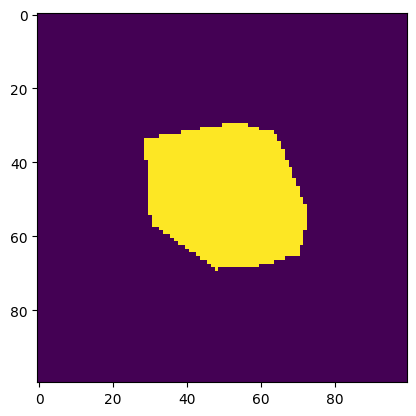

In [17]:
import scipy

def flood_fill_hull(image):    
    points = np.transpose(np.where(image))
    hull = scipy.spatial.ConvexHull(points)
    deln = scipy.spatial.Delaunay(points[hull.vertices]) 
    idx = np.stack(np.indices(image.shape), axis = -1)
    out_idx = np.nonzero(deln.find_simplex(idx) + 1)
    out_img = np.zeros(image.shape)
    out_img[out_idx] = 1
    return out_img, hull




points = tuple(np.rint(10 * np.random.randn(3,100)).astype(int) + 50)
image = np.zeros((100,)*3)
print(image.shape)
image[points] = 1


out, h = flood_fill_hull(image)

plt.imshow(out[50])

## 树突凸包

In [20]:
regionDendriteVolume={}
for key,neurons in regionNeurons.items():
    dendriteVolume={}
    for neuron in neurons:
        tree =iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        dendrite = tree.getDendrite()
        pointsx=[]
        pointsy=[]
        pointsz=[]
        for edge in dendrite:
            for p in edge.data:

                pointsx.append(p.x/10)
                pointsy.append(p.y/10)
                pointsz.append(p.z/10)
        if len(pointsx)==0:
            continue
        arrayx,arrayy,arrayz = np.array(pointsx),np.array(pointsy),np.array(pointsz)
        arrayx = arrayx-np.min(arrayx)
        arrayy = arrayy-np.min(arrayy)
        arrayz = arrayz-np.min(arrayz)
        points=tuple((np.rint(arrayx).astype(int),np.rint(arrayy).astype(int),np.rint(arrayz).astype(int)))
        image = np.zeros((int(arrayx.max()+2),int(arrayy.max()+2),int(arrayz.max()+2)))
        print(image.shape)
        image[points] = 1
        out, h = flood_fill_hull(image)
        dendriteVolume[neuron['sampleid']+neuron['name']]=np.sum(out)
    if len(dendriteVolume):
        regionDendriteVolume[key] =dendriteVolume
        # plt.imshow(out[int(arrayz.max()/2)])
        # plt.show()
        

exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/057.swc
(44, 68, 85)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220240/025.swc
(39, 58, 50)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/016.swc
(51, 52, 52)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/017.swc
(45, 47, 51)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/030.swc
(61, 77, 52)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/037.swc
(55, 74, 71)
exist  e:\workspace\project\neuron-vis\analyseCase/../neuronVis/../resource/swc/220241/038.swc


KeyboardInterrupt: 

In [19]:
regionDendriteVolume
# regionDendriteVolume['VPM'].keys()
regionname='VPL'
reneurons =[]
for neuron in list(regionDendriteVolume[regionname].keys()):
    neurondict={}
    neurondict['sampleid']=neuron[0:6]
    neurondict['name']=neuron[6:14]
    neurondict['mirror']=0
    reneurons.append(neurondict)
Scene.createScene(reneurons,'../resource/scene/TH_'+regionname+'.nv')

NameError: name 'regionDendriteVolume' is not defined

In [18]:
allvols = []
dataframe={}
for region,neurons in regionDendriteVolume.items():
    print(region)
    vols=[]
    for neuron,vol in neurons.items():
        vols.append(vol)
        allvols.append(int(vol/100))
    s = pd.Series(vols)
    dataframe[region]=s 
data = pd.DataFrame(dataframe)
plt.figure(figsize=(15, 7.5)) 
ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
data.boxplot(fontsize=15,showfliers=False)
ax.grid(False)
plt.xticks(rotation = 90)
# plt.xlabel('Soma Region')
plt.ylabel('Convex hull volume(μm3)',fontsize=10)
plt.xlabel('Soma location',fontsize=10)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
plt.savefig('../resource/svg/ConvexHullVolume.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式
plt.show()

# plt.figure(figsize=(5, 1)) 
# plt.hist(allvols,bins=20)
# # plt.xticks(rotation = 40)
# plt.xlabel('histogram of Convex Hull Volume')
# plt.ticklabel_format(axis="x", style="sci", scilimits=(0,0))
# plt.ylabel('Neuron Count')


NameError: name 'regionDendriteVolume' is not defined

In [33]:
regionNeurons

{'VPM': [{'color': {'r': '104', 'g': '131', 'b': '250'},
   'name': '146.swc',
   'sampleid': '210661'},
  {'color': {'r': '224', 'g': '103', 'b': '30'},
   'name': '169.swc',
   'sampleid': '210661'},
  {'color': {'r': '90', 'g': '107', 'b': '8'},
   'name': '062.swc',
   'sampleid': '210726'},
  {'color': {'r': '35', 'g': '125', 'b': '194'},
   'name': '080.swc',
   'sampleid': '210726'},
  {'color': {'r': '29', 'g': '218', 'b': '244'},
   'name': '131.swc',
   'sampleid': '210726'},
  {'color': {'r': '166', 'g': '107', 'b': '126'},
   'name': '132.swc',
   'sampleid': '210726'},
  {'color': {'r': '231', 'g': '69', 'b': '218'},
   'name': '022.swc',
   'sampleid': '210727'},
  {'color': {'r': '38', 'g': '203', 'b': '113'},
   'name': '072.swc',
   'sampleid': '211181'}],
 'VPL': [{'color': {'r': '204', 'g': '228', 'b': '38'},
   'name': '154.swc',
   'sampleid': '210661'},
  {'color': {'r': '161', 'g': '149', 'b': '19'},
   'name': '065.swc',
   'sampleid': '210726'},
  {'color': {'r

186
range(0, 16) ['VPM', 'VPL', 'VPMpc', 'VPLpc', 'VAL', 'MD', 'LP', 'PO', 'CM', 'TH', 'ar', 'CL', 'Eth', 'PIL', 'PoT', 'SPFp'] [8, 25, 2, 4, 6, 39, 3, 32, 6, 5, 13, 13, 6, 1, 20, 3]


Text(29.59722222222222, 0.5, 'No. of neuron')

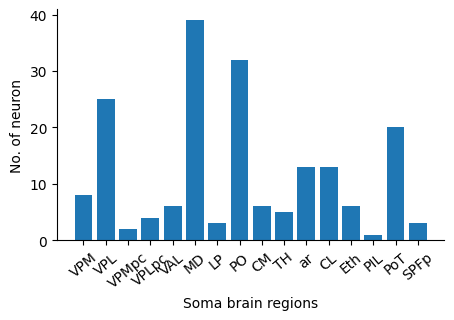

In [34]:

# regionNeurons
label=[] 
regionNeuronCount=[]
neucount=0
for key,neurons in regionNeurons.items():
    neucount+=len(neurons)
    # print(key,len(neurons))
    if len(neurons)>0:
        label.append(key)
        regionNeuronCount.append(len(neurons))

x = range(len(regionNeuronCount))
print(neucount)
print(x,label,regionNeuronCount)
fig,ax = plt.subplots(figsize=(5,3))
# ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(x,label,rotation = 40)
plt.bar(x,regionNeuronCount)
plt.savefig('../resource/svg/fig1.pdf',format='pdf')#保存为.svg格式
plt.xlabel('Soma brain regions')
plt.ylabel('No. of neuron')

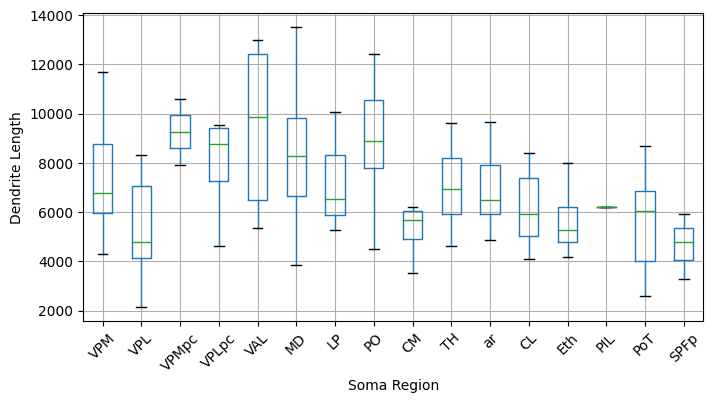

Text(0, 0.5, 'Neuron Count With Dendrite')

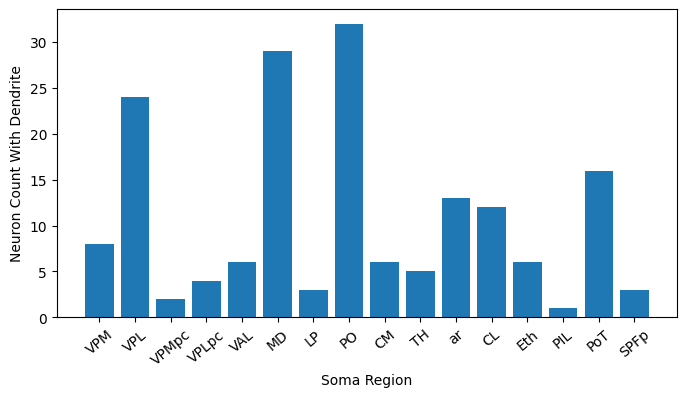

In [35]:
from re import S
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
dataframe={}
label=[] 
regionNeuronCount=[]
for region in regionpropmat.keys():
    label.append(region)   
    regionNeuronCount.append(len(regionpropmat[region]))
    s = pd.Series(regionpropmat[region])
    if s.size>0:
        dataframe[region]=s 
data = pd.DataFrame(dataframe)
plt.figure(figsize=(8, 4)) 
data.boxplot()
plt.xticks(rotation=45)
plt.xlabel('Soma Region')
plt.ylabel('Dendrite Length')
plt.show()

x = range(len(regionpropmat))

fig,ax = plt.subplots(figsize=(8,4))
plt.xticks(x,label,rotation = 40)
plt.bar(x,regionNeuronCount)
plt.xlabel('Soma Region')
plt.ylabel('Neuron Count With Dendrite')

In [6]:
import Visual as nv
import random
neuronvis = nv.neuronVis(renderModel=1)
neuronvis.render.setBackgroundColor((1.0,1.0,1.0,1.0))
neuronvis.clear(root=True,regions=False)
neuronvis.addRegion('TH')
neuronvis.render.setLookAt((-5000.,0.0,0),(0,0,0),(0.0,-1.0,0.0))
	# break


for region,neuronsInRegion in regionNeurons.items():
    regionprop=[]
    propmat2=[]
    for neuron in neuronsInRegion:
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        print(neuron)

        if property['dendritelength']!=0:
            neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
            color=[1,0,0]
            neuronvis.addNeuronTree(neuronT,'200313-083.swc',color=color,axonHide=True)
            neuronvis.render.savepng('../resource/thsample/dendrite/'+region+neuron['sampleid']+neuron['name']+'.png')
            neuronvis.clear(root=True,regions=False)
            pass
neuronvis.render.closeWindow()

specified material (mtl1)  not loaded!


{'sampleid': '210661', 'name': '146.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/146.swc
{'sampleid': '210661', 'name': '169.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/169.swc
{'sampleid': '210726', 'name': '062.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/062.swc
{'sampleid': '210726', 'name': '080.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/080.swc
{'sampleid': '210726', 'name': '131.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/131.swc
{'sampleid': '210726', 'name': '132.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/132.swc
{'sampleid': '210727', 'name': '022.swc'}
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/022.swc
{'sampleid': '211181', 'name': '072.swc'}
exist  d:\project\python\neuron-vis\figures/../n

## axon Length

In [37]:
import BrainRegion as BR 
import numpy as np
br = BR.BrainRegion()
br.praseJson()


# neurons = Scene.scene2List("../resource/TH.nv")
neurons = neuronScene
#target_regions = ['SSp','SSs','VISC','GU','VISp','VISam','VISpm','VISa','AUDp','AUDv','AUDd','TEa','MOp','MOs','ORBl','ORBvl','ORBm','PL','AIv','AIp','AId','ACAd','ACAv','RSPagl','RSPd']
target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT',
'STRd','STRv','sAMY','MB','TH','HY','OLF','HPF','CTXsp','PAL']

source_regions_sort_index = ['VPM','VPL','VPMpc','VPLpc','LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp','PF']
source_regions_color=[[179,238,58],[0,100,0],[255,0,0],[0,0,255],[139,101,8],[205,104,57],
[255,0,255],[255,250,205],[255,20,147],[255,225,255],[207,207,207],[144,238,144],
[180,205,205],[110,123,139],[205,201,165],[238,106,167],[255,228,196],[216,191,216],
[238,154,0],[205,133,0],[205,91,69],[255,20,147],[255,52,179],[0,191,255],[150,191,200]
]
regionNeurons={}
for regions in source_regions_sort_index:
    regionNeurons[regions]=[]
for neuron in neurons:
    neuron['mirror']=0
    property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
    if property['somaregion'] not in source_regions_sort_index:
        continue
    else:
        regionNeurons[property['somaregion']].append(neuron)
# print(regionNeurons)
propmat=[]
regionpropmat=[]
for region,neuronsInRegion in regionNeurons.items():
    regionprop=[]
    propmat2=[]
    for neuron in neuronsInRegion:
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])
        prop=[]
        for targetRegion in target_regions:
            regionsum = brproperty.getSumProperty(targetRegion)
            regionleft = brpropertyLeft.getSumProperty(targetRegion)
            regionright = brpropertyRight.getSumProperty(targetRegion)
            ipsi=0
            contra=0
            if property['somapoint'][2]<5700:
                ipsi=regionleft
                contra=regionright
            else:
                ipsi=regionright
                contra=regionleft
            prop.append(ipsi)
        propmat.append(prop)
        propmat2.append(prop)
    if len(propmat2)>0:
        temp = np.array(propmat2)
        regionprop = temp.sum(0)
        regionpropmat.append(list(regionprop))


In [38]:
len(source_regions_color)

25

In [18]:
for region in source_regions_sort_index:
    for neuron in regionNeurons[region]:
        neuron['mirror']=1
    Scene.createScene(regionNeurons[region],"../resource/scene/TH_"+region+".nv")

In [25]:
Scene.createScene(regionNeurons['VPM'],"../resource/TH_VPM.nv")
# regionNeurons['VPL']
list2=[]
for region in source_regions_sort_index:
    for neuron in regionNeurons[region]:
            list2.append("D:/project/python/neuron-vis/resource/swc/"+neuron['sampleid']+"/"+neuron['name'])

f=open("../resource/allthneurons.txt","w")
 
for line in list2:
    f.write(line+'\n')
f.close()

In [39]:
print(neucount)

186


range(0, 18) ['VPM', 'VPL', 'VPMpc', 'VPLpc', 'VAL', 'MD', 'LP', 'PO', 'CM', 'TH', 'ar', 'CL', 'Eth', 'PIL', 'PoT', 'SPFp', 'PF', 'Other'] [8, 25, 2, 4, 6, 39, 3, 32, 6, 5, 13, 13, 6, 1, 20, 3, 1, 25]


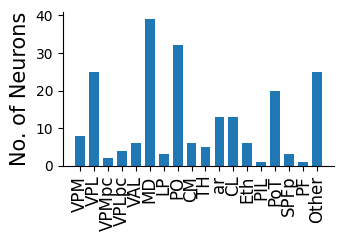

In [40]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
# regionNeurons
label=[] 
regionNeuronCount=[]
for key,neurons in regionNeurons.items():
    if len(neurons)>0:
        label.append(key)
        regionNeuronCount.append(len(neurons))
regionNeuronCount.append(len(neuronScene)-neucount)
label.append('Other')
x = range(len(regionNeuronCount))

print(x,label,regionNeuronCount)
fig,ax = plt.subplots(figsize=(3.5,2.))
# ax=plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(x,label,rotation = 90,fontsize=12)
plt.bar(x,regionNeuronCount,width=0.7)
# plt.xlabel('Soma Region')
plt.ylabel('No. of Neurons',fontsize=15)
plt.savefig('../resource/svg/CountofNeuron.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式

## 主干

In [18]:
import NeuronProcess
import IONData,Scene,SwcLoader

import Visual as nv
import json
neuronvis = nv.neuronVis(renderModel=0)

neuronvis.render.setBackgroundColor((0.0,0.0,0.,1.0))

iondata = IONData.IONData()

neuronvis.render.setView(type='left')
edgesForCluster=[]
for key,neurons in regionNeurons.items():
    if key !='ar':
        continue
    regeionname=key
    for neuron in regionNeurons[regeionname][:]:
        print(neuron['sampleid'], neuron['name'])
        neuronT = iondata.getNeuronTreeByID(neuron['sampleid'], neuron['name'])
        neuronT.dendriteHide=True
        NeuronProcess.CalculateBranchMaxDepth(neuronT)
        mainbranch=[]
        if neuronT.rootAxonEdge is None:
            continue
        for edge in neuronT.edges:

            if edge.maxDepth>neuronT.rootAxonEdge.maxDepth*0.7 or edge.maxLength>neuronT.rootAxonEdge.maxLength*0.3:
                edge.order=0
                mainbranch.append(edge)
        for edge in mainbranch:
            for child in edge.children:
                if child.order!=0:
                    NeuronProcess.OrderChildren(neuronT,child,1)
            pass
        # for child in neuronT.rootAxonEdge.children:
        # 	# if child.order!=0:
        # 		NeuronProcess.OrderChildren(neuronT,child,1)

        for edge in mainbranch:
            for child in edge.children:
                if child.order!=0:
                    NeuronProcess.GetFirstOrderEdges(edgesForCluster,child)

        newneuron=SwcLoader.NeuronTree()
        if len(mainbranch):
            newneuron.edges= mainbranch
            newneuron.rootAxonEdge = neuronT.rootAxonEdge
            newneuron.root=neuronT.root
        neuronvis.addNeuronTree(newneuron,'neuronname',depthIntensity=False)
        # neuronvis.render.savepng('../resource/mainbranch/'+regeionname+neuron['sampleid']+neuron['name']+'.png')
        # neuronvis.clear()
neuronvis.render.run()
neuronvis.render.closeWindow()

210726 070.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210726/070.swc
210726 071.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210726/071.swc
210726 072.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210726/072.swc
210727 002.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210727/002.swc
210727 003.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210727/003.swc
210727 005.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210727/005.swc
210727 018.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210727/018.swc
210727 019.swc
exist  c:\Users\xfwang\Documents\workspace\neuron-vis\figures/../neuronVis/../resource/swc/210727/019.swc
210727 030.swc
exist  c:\Users\x

OSError: exception: access violation reading 0x0000000000000000

([], [])

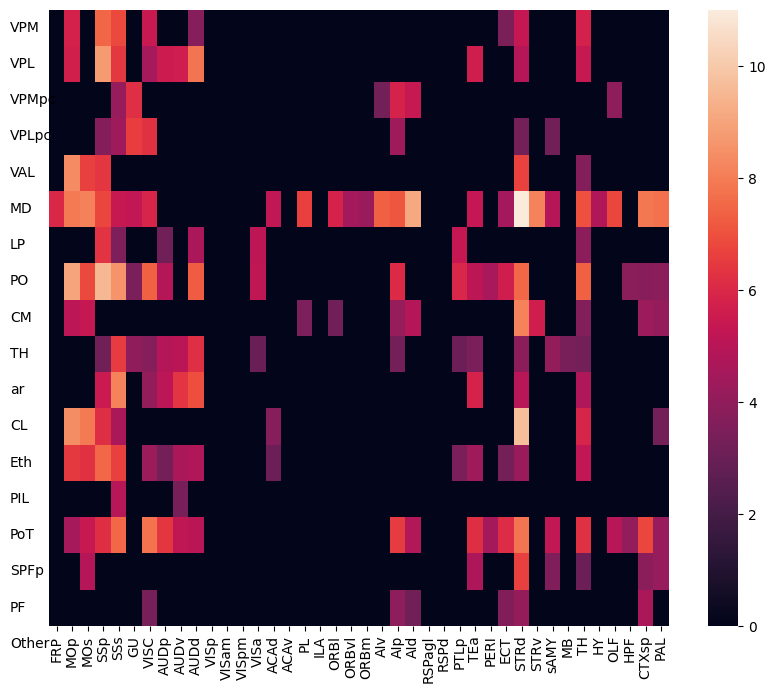

In [41]:
import numpy as np 
import seaborn	as sns


mat = np.array(regionpropmat)
mat = np.log2(mat/1000.0+1)
mat[mat<3]=0
fig,ax = plt.subplots(figsize=(10,8))

sns.heatmap(mat)
plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
sum=0
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        # y = regionNeuronCount[index]/2+sum+1
        sum+=1
        plt.text(-2.5,sum-0.4,label[index])

plt.yticks([])

In [42]:
mat = np.array(propmat)
mat.shape
# np.sum(mat,0)

(187, 40)

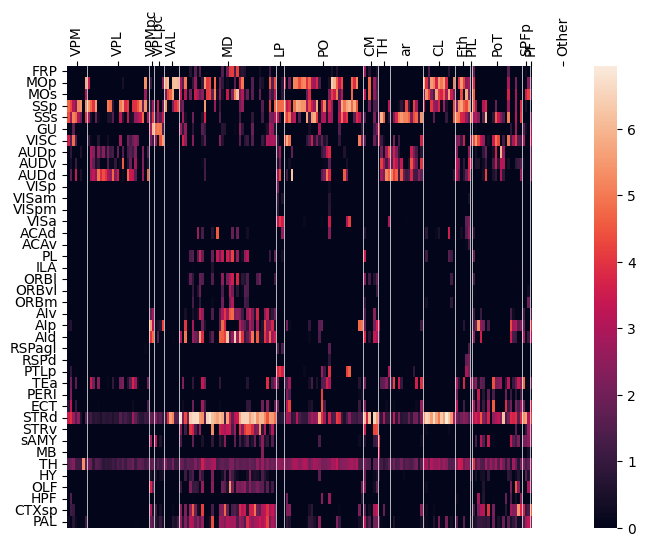

In [43]:
import numpy as np 
import seaborn	as sns


mat = np.array(propmat)
mat = np.log2(mat/1000.0+1)

fig,ax = plt.subplots(figsize=(8,6))

sns.heatmap(mat.T)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)
sum=0
yindex=[]
ylabels=[]
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        y = regionNeuronCount[index]/2+sum
        sum+=regionNeuronCount[index]
        yindex.append(y)
        ylabels.append(label[index])
plt.xticks(yindex,ylabels)

sum=0
for i in range(len(regionNeuronCount)):
    index  = i
    if regionNeuronCount[index]>0:
        sum+=regionNeuronCount[index]
        plt.axvline(x=sum,ls="-",c="white", linewidth=0.5)
# plt.yticks([])
ax.xaxis.tick_top()
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.savefig('../resource/svg/regionProject.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式

In [44]:
matdf = pd.DataFrame(mat,columns=target_regions)


In [45]:
matdf.shape[0]

187

([<matplotlib.axis.YTick at 0x20e2ba9c6a0>,
 [Text(0, 0.5, 'FRP'),
  Text(0, 1.5, 'MOp'),
  Text(0, 2.5, 'MOs'),
  Text(0, 3.5, 'SSp'),
  Text(0, 4.5, 'SSs'),
  Text(0, 5.5, 'GU'),
  Text(0, 6.5, 'VISC'),
  Text(0, 7.5, 'AUDp'),
  Text(0, 8.5, 'AUDv'),
  Text(0, 9.5, 'AUDd'),
  Text(0, 10.5, 'VISp'),
  Text(0, 11.5, 'VISam'),
  Text(0, 12.5, 'VISpm'),
  Text(0, 13.5, 'VISa'),
  Text(0, 14.5, 'ACAd'),
  Text(0, 15.5, 'ACAv'),
  Text(0, 16.5, 'PL'),
  Text(0, 17.5, 'ILA'),
  Text(0, 18.5, 'ORBl'),
  Text(0, 19.5, 'ORBvl'),
  Text(0, 20.5, 'ORBm'),
  Text(0, 21.5, 'AIv'),
  Text(0, 22.5, 'AIp'),
  Text(0, 23.5, 'AId'),
  Text(0, 24.5, 'RSPagl'),
  Text(0, 25.5, 'RSPd'),
  Text(0, 26.5, 'PTLp'),
  Text(0, 27.5, 'TEa'),
  Text(0, 28.5, 'PERI'),
  Text(0, 29.5, 'ECT'),
  Text(0, 30.5, 'STRd'),
  Text(0, 31.5, 'STRv'),
  Text(0, 32.5, 'sAMY'),
  Text(0, 33.5, 'MB'),
  Text(0, 34.5, 'TH'),
  Text(0, 35.5, 'HY'),
  Text(0, 36.5, 'OLF'),
  Text(0, 37.5, 'HPF'),
  Text(0, 38.5, 'CTXsp'),
  Text(0

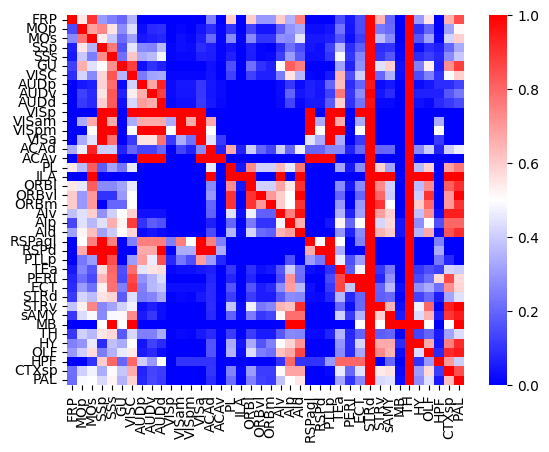

In [12]:
score=np.zeros([len(target_regions),len(target_regions)])
for i in range(len(target_regions)):
    region  =target_regions[i]
    temp = matdf[matdf[region]>0.5]
    for  j in range(len(target_regions)):
        region1  =target_regions[j]

        temp1 =temp[temp[region1]>0.5]
        if temp.shape[0]>0:
            score[i,j]=temp1.shape[0]/temp.shape[0]
sns.heatmap(score,cmap='bwr')
plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)

In [46]:
target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT']
propmat0=[]
columes =  []
for region in source_regions_sort_index:

    for neuron in regionNeurons[region]:
            property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                columes.append(neuron['sampleid']+neuron['name'])
                propmat0.append(prop)

import numpy as np 
import seaborn	as sns




In [47]:
len(columes)

183

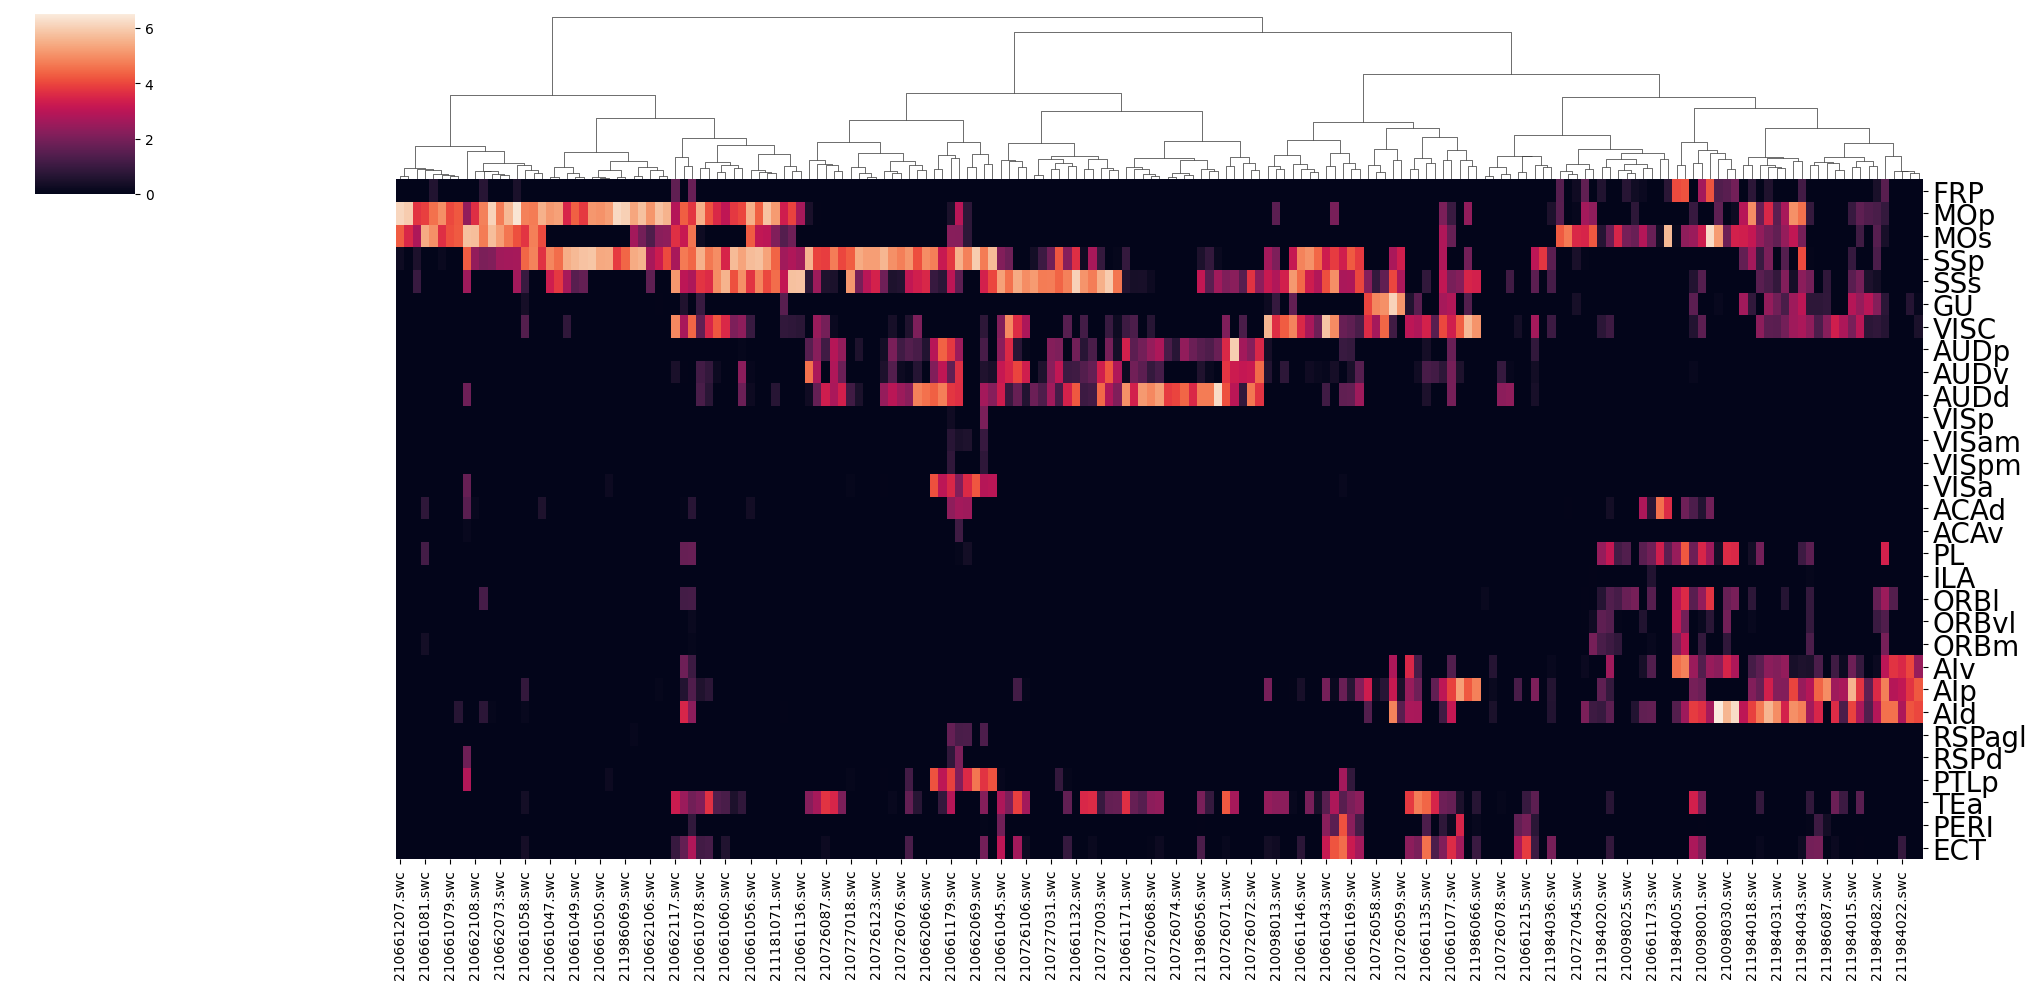

In [48]:
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
df = pd.DataFrame(mat0.T,index=target_regions,columns=columes)

cg = sns.clustermap(df,figsize=[20,10],method='ward',metric='euclidean',row_cluster=False)
# plt.xticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 90)
# plt.yticks(fontproperties='Times New Roman', size=25)
plt.setp(cg.ax_heatmap.yaxis.get_majorticklabels(), size=20)
plt.show()
# plt.yticks([])

([<matplotlib.patches.Wedge at 0x22cb492aeb0>,
 [Text(1.0683826988430793, 0.2618366070907169, '0'),
  Text(0.3435085919907754, 1.0449889220601887, '1'),
  Text(-1.0941698717691444, 0.11310301372065325, '2'),
  Text(0.06605396419212634, -1.0980149697588397, '3'),
  Text(0.9839358319684992, -0.49180308922215754, '4'),
  Text(1.094169872761907, -0.11310300411656803, '5'),
  Text(1.0993517007991291, -0.03776026946490459, '6')],
 [Text(0.5827541993689522, 0.14281996750402737, '7.7%'),
  Text(0.18736832290405928, 0.5699939574873756, '24.6%'),
  Text(-0.5968199300558968, 0.06169255293853813, '32.2%'),
  Text(0.03602943501388709, -0.5989172562320942, '23.0%'),
  Text(0.5366922719828177, -0.2682562304848132, '10.4%'),
  Text(0.5968199305974037, -0.06169254769994619, '1.1%'),
  Text(0.5996463822540704, -0.020596510617220683, '1.1%')])

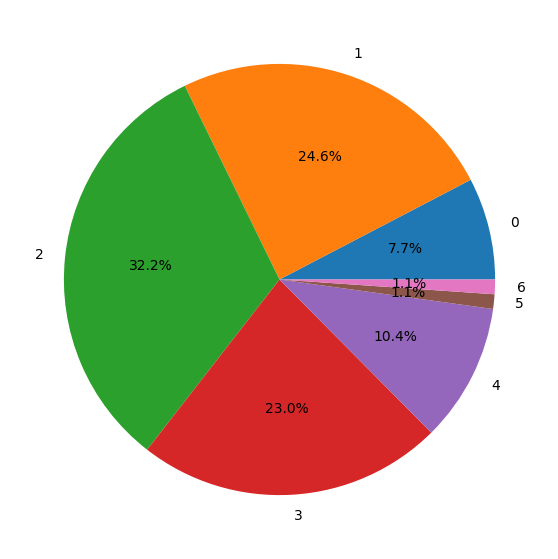

In [49]:

from collections import Counter
threshold=3
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
mat0[mat0>threshold]=threshold
mat0[mat0<threshold]=0
mat0=mat0/threshold
df = pd.DataFrame(mat0.T,index=target_regions,columns=columes)
# sns.heatmap(df)
projectCount = mat0.sum(1)
projectCountsum= Counter(projectCount)
projectCountsumdict=dict(projectCountsum)
projectCountsumdict = dict([(k,projectCountsumdict[k]) for k in sorted(projectCountsumdict.keys())])
projectCountsumdict
# print(propmat0)
# del projectCountsumdict[0.0]
labels = np.array(list(projectCountsumdict.keys())).astype(np.int8).tolist()
# projectCountsumdict.values()
fig,ax = plt.subplots(figsize=(7,7))
plt.pie(projectCountsumdict.values(),labels=labels,autopct = '%1.1f%%')

In [50]:
df

,210661146.swc,210661169.swc,210726062.swc,210726080.swc,210726131.swc,210726132.swc,211181072.swc,210661154.swc,210726065.swc,210726066.swc,...,210662117.swc,210726108.swc,210726109.swc,210726110.swc,210727029.swc,211986058.swc,210726063.swc,210727045.swc,210727059.swc,210661077.swc
FRP,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MOp,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MOs,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
SSp,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
SSs,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
GU,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VISC,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
AUDp,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AUDv,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AUDd,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


{'VPM':         210661146.swc  210661169.swc  210726062.swc  210726080.swc  \
FRP               0.0            0.0            0.0            0.0   
MOp               0.0            0.0            0.0            0.0   
MOs               0.0            0.0            0.0            0.0   
SSp               1.0            1.0            1.0            0.0   
SSs               1.0            0.0            1.0            1.0   
GU                0.0            0.0            0.0            0.0   
VISC              1.0            0.0            1.0            0.0   
AUDp              0.0            0.0            0.0            0.0   
AUDv              0.0            0.0            0.0            0.0   
AUDd              0.0            0.0            0.0            1.0   
VISp              0.0            0.0            0.0            0.0   
VISam             0.0            0.0            0.0            0.0   
VISpm             0.0            0.0            0.0            0.0   
VISa        

Text(0, 0.5, 'Nueron number (%)')

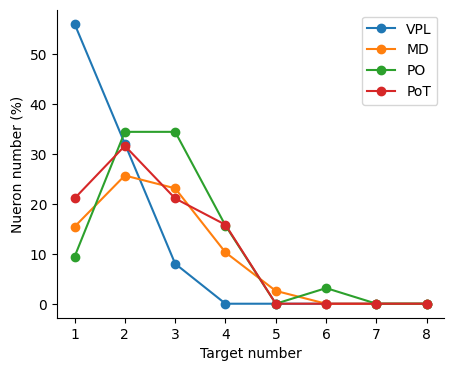

In [51]:
from collections import Counter
fig,ax = plt.subplots(figsize=(5,4))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

regionDFdict={}
for region in source_regions_sort_index:
    regionneuronname=[]
    for neuron in regionNeurons[region]:
        if neuron['sampleid']+neuron['name'] in df.columns:
            regionneuronname.append(neuron['sampleid']+neuron['name'])
    if len(regionneuronname)>0:
        regiondf = df[regionneuronname]
        regionDFdict[region]=regiondf
print(regionDFdict)
for region  in regionDFdict:
    # print(regionDFdict[region].shape[1],regionDFdict[region].sum(axis=0))
    if regionDFdict[region].shape[1]<15:
        continue
    projectCountsum= Counter(regionDFdict[region].sum(axis=0))
    # print(projectCountsum)
    x = range(1,9)
    y=[]
    for i in x:
        y.append(projectCountsum[i]/regionDFdict[region].shape[1]*100)
    print(y)
    plt.plot(x,y,marker='o',label=region)
plt.legend()
plt.xlabel('Target number')
plt.ylabel('Nueron number (%)')

32
[50.0, 31.25, 15.625, 0.0, 0.0, 0.0, 0.0, 0.0]
151
[19.205298013245034, 32.450331125827816, 24.503311258278146, 12.582781456953644, 1.3245033112582782, 1.3245033112582782, 0.0, 0.0]


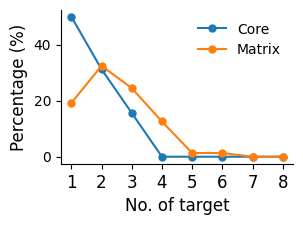

In [52]:
from collections import Counter
fig,ax = plt.subplots(figsize=(3,2))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

regionDFdict={}
coreNeuronName=[]
matrixNeuronName=[]
for region in source_regions_sort_index:
    NeuronName=[]
    regionname = 'Matrix'

    for neuron in regionNeurons[region]:
        if neuron['sampleid']+neuron['name'] in df.columns:
            NeuronName.append(neuron['sampleid']+neuron['name'])


    if len(NeuronName)>0:
        if region=='VPM' or region=='VPL':
            regionname = 'Core'
            coreNeuronName.extend(NeuronName)
        else:
            matrixNeuronName.extend(NeuronName)
regiondf = df[coreNeuronName]
regionDFdict['Core']=regiondf
regiondf = df[matrixNeuronName]
regionDFdict['Matrix']=regiondf
for region  in regionDFdict:
    print(regionDFdict[region].shape[1])
    if regionDFdict[region].shape[1]<15:
        continue
    projectCountsum= Counter(regionDFdict[region].sum(axis=0))
    x = range(1,9)
    y=[]
    for i in x:
        y.append(projectCountsum[i]/regionDFdict[region].shape[1]*100)
    print(y)
    plt.plot(x,y,marker='o',markersize=5,label=region)
plt.legend(edgecolor='w',fontsize=10)
plt.xticks(range(1,9),fontsize=12)
plt.xlabel('No. of target',fontsize=12)
plt.ylabel('Percentage (%)',fontsize=12)
plt.savefig('../resource/svg/figcorematrix.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式


In [53]:
projectCountsumCore= Counter(regionDFdict['Core'].sum(axis=0))
projectCountsumMatrix= Counter(regionDFdict['Matrix'].sum(axis=0))
projectCountsumMatrix
corelist=[]
matrixlist=[]
for i in range(7):
    corelist.append(projectCountsumCore[i])
    matrixlist.append(projectCountsumMatrix[i])
print(corelist[0:4],matrixlist)

[1, 16, 10, 5] [13, 29, 49, 37, 19, 2, 2]


In [88]:
#知道这两组的值
import scipy.stats as stats

stats.mannwhitneyu(corelist,matrixlist,alternative='two-sided')
# stats.ranksums(corelist[0:4],matrixlist)
#MannwhitneyuResult(statistic=62.0,pvalue=0.0993422478534652) 
#大于0.05，也就是接受原假设

MannwhitneyuResult(statistic=7.0, pvalue=0.028946478690258817)

In [65]:
coreseries=(regionDFdict['Core'].sum(axis=0))
matrixseries=(regionDFdict['Matrix'].sum(axis=0))

D:\project\python\AppData\Local\Temp\ipykernel_24496\835305555.py:12: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['Core','Matrix'],rotation = 90,fontsize = 'small')


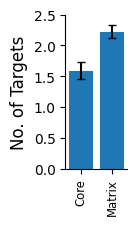

In [66]:
data = [coreseries,matrixseries]
mean=[coreseries.mean(),matrixseries.mean()]
sem=[coreseries.sem(),matrixseries.sem()]
# data=pd.DataFrame(data)
fig,ax=plt.subplots(figsize=[0.8,2])
plt.bar(['Core','Matrix'], mean, yerr=sem, capsize=3,
              edgecolor="white", linewidth=0.7)
# view = plt.boxplot(data,widths=0.6)
# ax.set_xticks(['Core','Matrix'])
plt.ylabel('No. of Targets',fontsize=12)

ax.set_xticklabels(['Core','Matrix'],rotation = 90,fontsize = 'small')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0,2.5)
plt.savefig('../resource/svg/figcorematrixbox.pdf',format='pdf',bbox_inches = 'tight')#保存为.svg格式
plt.show()


In [39]:
dfT = df.T
# dfT[dfT['STRd']>3].index.tolist()
strdneuronlist = dfT.sort_values(by='STRd').index.tolist()
# target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
# 'RSPagl','RSPd','PTLp','TEa','PERI','ECT']
target_layerRegions0=[
# ['FRP1','FRP2/3','FRP5','FRP6a','FRP6b'],
['MOp1','MOp2/3','MOp5','MOp6a','MOp6b'],
['MOs1','MOs2/3','MOs5','MOs6a','MOs6b'],
# ['SSp-n1','SSp-n2/3','SSp-n4','SSp-n5','SSp-n6a','SSp-n6b'],
# ['SSp-bfd1','SSp-bfd2/3','SSp-bfd4','SSp-bfd5','SSp-bfd6a','SSp-bfd6b'],
# ['SSp-ll1','SSp-ll2/3','SSp-ll4','SSp-ll5','SSp-ll6a','SSp-ll6b'],
# ['SSp-m1','SSp-m2/3','SSp-m4','SSp-m5','SSp-m6a','SSp-m6b'],
# ['SSp-ul1','SSp-ul2/3','SSp-ul4','SSp-ul5','SSp-ul6a','SSp-ul6b'],
# ['SSp-tr1','SSp-tr2/3','SSp-tr4','SSp-tr5','SSp-tr6a','SSp-tr6b'],
# ['GU1','GU2/3','GU4','GU5','GU6a','GU6b'],
# ['VISC1','VISC2/3','VISC4','VISC5','VISC6a','VISC6b'],
# ['AUDd1','AUDd2/3','AUDd4','AUDd5','AUDd6a','AUDd6b'],
# ['AUDp1','AUDp2/3','AUDp4','AUDp5','AUDp6a','AUDp6b'],
# ['AUDpo1','AUDpo2/3','AUDpo4','AUDpo5','AUDpo6a','AUDpo6b'],
# ['AUDv1','AUDv2/3','AUDv4','AUDv5','AUDv6a','AUDv6b'],
# ['VISal1','VISal2/3','VISal4','VISal5','VISal6a','VISal6b'],
# ['VISam1','VISam2/3','VISam4','VISam5','VISam6a','VISam6b'],
# ['VISl1','VISl2/3','VISl4','VISl5','VISl6a','VISl6b'],
# ['VISp1','VISp2/3','VISp4','VISp5','VISp6a','VISp6b'],
# ['VISpl1','VISpl2/3','VISpl4','VISpl5','VISpl6a','VISpl6b'],
# ['VISpm1','VISpm2/3','VISpm4','VISpm5','VISpm6a','VISpm6b'],
# ['VISli1','VISli2/3','VISli4','VISli5','VISli6a','VISli6b'],
# ['VISpor1','VISpor2/3','VISpor4','VISpor5','VISpor6a','VISpor6b'],
# ['ACAd1','ACAd2/3','ACAd5','ACAd6a','ACAd6b'],
# ['ACAv1','ACAv2/3','ACAv5','ACAv6a','ACAv6b'],
# ['PL1','PL2','PL2/3','PL5','PL6a','PL6b'],
# ['ILA1','ILA2','ILA2/3','ILA5','ILA6a','ILA6b'],
# ['ORBl1','ORBl2/3','ORBl5','ORBl6a','ORBl6b'],
# ['ORBm1','ORBm2/3','ORBm5','ORBm6a','ORBm6b'],
# ['ORBvl1','ORBvl2/3','ORBvl5','ORBvl6a','ORBvl6b'],
['AId1','AId2/3','AId5','AId6a','AId6b'],
['AIp1','AIp2/3','AIp5','AIp6a','AIp6b'],
['AIv1','AIv2/3','AIv5','AIv6a','AIv6b'],
# ['RSPagl1','RSPagl2/3','RSPagl5','RSPagl6a','RSPagl6b'],
# ['RSPd1','RSPd2/3','RSPd5','RSPd6a','RSPd6b'],
# ['RSPv1','RSPv2/3','RSPv5','RSPv6a','RSPv6b'],
# ['VISa1','VISa2/3','VISa4','VISa5','VISa6a','VISa6b'],
# ['VISrl1','VISrl2/3','VISrl4','VISrl5','VISrl6a','VISrl6b'],
# ['TEa1','TEa2/3','TEa4','TEa5','TEa6a','TEa6b'],
# ['PERI1','PERI2/3','PERI5','PERI6a','PERI6b'],
# ['ECT1','ECT2/3','ECT5','ECT6a','ECT6b']

]
target_layerRegions=[]
for regions in target_layerRegions0:
    for region in regions:
        target_layerRegions.append(region)
propmat0=[]
columes =  []

for neuron in strdneuronlist:
        print(neuron)
        property = iondata.getNeuronPropertyByID(neuron[0:6], neuron[6:])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
        brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        brpropertyLeft.setProperty(property['projectleftregion'])
        brpropertyRight.setProperty(property['projectrightregion'])
        prop=[]
        for targetRegion in target_layerRegions:
            regionsum = brproperty.getSumProperty(targetRegion)
            regionleft = brpropertyLeft.getSumProperty(targetRegion)
            regionright = brpropertyRight.getSumProperty(targetRegion)
            ipsi=0
            contra=0
            if property['somapoint'][2]<5700:
                ipsi=regionleft
                contra=regionright
            else:
                ipsi=regionright
                contra=regionleft
            prop.append(ipsi)
        if np.array(prop).sum()>10:
            columes.append(neuron[0:6]+neuron[6:])
            propmat0.append(prop)
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
dfstrd = pd.DataFrame(mat0.T,index=target_layerRegions,columns=columes)

KeyError: 'STRd'

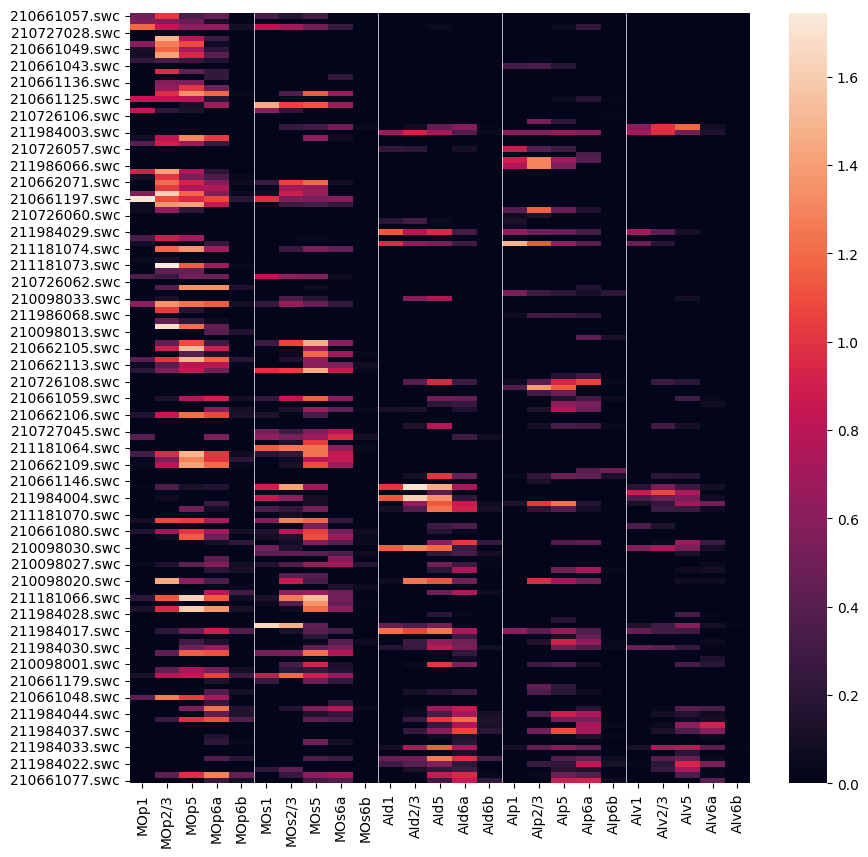

In [17]:
mat0 = np.array(propmat0)
mat0 = np.log10(mat0/1000.0+1)
# fig,ax = plt.subplots(figsize=(7,13))
dfstrd = pd.DataFrame(mat0.T,index=target_layerRegions,columns=columes)
fig,ax = plt.subplots(figsize=(10,10))

sns.heatmap(dfstrd.T)
sum=0
for regions in target_layerRegions0:
    sum+=len(regions)
    plt.axvline(x=sum,ls="-",c="white", linewidth=0.5)


In [54]:
from collections import Counter
threshold=2
mat0 = np.array(propmat0)
mat0 = np.log2(mat0/1000.0+1)
mat0[mat0>threshold]=threshold
mat0[mat0<threshold]=0
mat0.shape

(183, 30)

In [25]:
df.to_csv('../resource/thsample/matrixdf.csv')

In [56]:
from scipy.cluster.hierarchy import linkage ,fcluster,fclusterdata,dendrogram
from scipy import spatial

from sklearn.cluster import AgglomerativeClustering



183


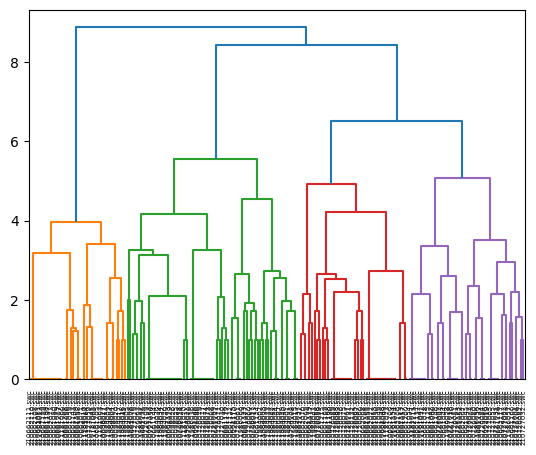

In [72]:
def fclusterDF(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=4.4,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:])
		return cluster
clusterproject = fclusterDF(df)
print(len(clusterproject))
# ac = AgglomerativeClustering(n_clusters=3, affinity='euclidean', linkage='ward')
# clustering = ac.fit(df)
# print("每个数据所属的簇编号", clustering.labels_,len(clustering.labels_))
# print("每个簇的成员", clustering.children_,len(clustering.children_))

In [68]:
regionNeurons['VPM']

[{'color': {'r': '104', 'g': '131', 'b': '250'},
  'name': '146.swc',
  'sampleid': '210661',
  'mirror': 0},
 {'color': {'r': '224', 'g': '103', 'b': '30'},
  'name': '169.swc',
  'sampleid': '210661',
  'mirror': 0},
 {'color': {'r': '90', 'g': '107', 'b': '8'},
  'name': '062.swc',
  'sampleid': '210726',
  'mirror': 0},
 {'color': {'r': '35', 'g': '125', 'b': '194'},
  'name': '080.swc',
  'sampleid': '210726',
  'mirror': 0},
 {'color': {'r': '29', 'g': '218', 'b': '244'},
  'name': '131.swc',
  'sampleid': '210726',
  'mirror': 0},
 {'color': {'r': '166', 'g': '107', 'b': '126'},
  'name': '132.swc',
  'sampleid': '210726',
  'mirror': 0},
 {'color': {'r': '231', 'g': '69', 'b': '218'},
  'name': '022.swc',
  'sampleid': '210727',
  'mirror': 0},
 {'color': {'r': '38', 'g': '203', 'b': '113'},
  'name': '072.swc',
  'sampleid': '211181',
  'mirror': 0}]

In [73]:
import Visual as nv

# neuronvis = nv.neuronVis(renderModel=0)
# neuronvis.render.setBackgroundColor((1.0,1.0,1.0,1.0))
# neuronvis.render.setView('dorsal')
# neuronsarray =np.array(df.columns)

for i in range(max(clusterproject)):
    neurons = df.columns[clusterproject==(i+1)]
    
    neuronscene=[]
    for neuron in neurons:
        scene={}
        scene['sampleid']= neuron[0:6]
        scene['name']=neuron[6:]
        neuronscene.append(scene)
    Scene.createScene(neuronscene,'../resource/thsample/matrix/thmatrixclusterWithSTR'+str(i+1)+'.nv')
    
    # for neuron in neurons:
    #     neuronT = iondata.getNeuronTreeByID(neuron[0:6], neuron[6:])
    #     neuronvis.addNeuronTree(neuronT,neuron,somaColor=[1,0,0],axonColor=[1,0,0],dendriteColor=[1,0,0])
    # neuronvis.render.savepng("../resource/thsample/matrix/cluster"+str(i+1)+'.png')
    # neuronvis.clear()

In [74]:

import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
color=[[255,0,0],[0,255,0],[0,0,255],[128,128,128],[255,0,255],[60,255,175],[255,155,0],[105,155,55],[155,155,205],[132,191,150],[]]
isoprojectmat=[]
columes2=[]
for region,neuronsInRegion in regionNeurons.items():
    # if region=='VPM' or region=='VPL':
    #     continue
    for neuron in neuronsInRegion:
        
        # property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        path = "../resource/swc/"+neuron['sampleid']+"/"+neuron['name']+"isoprojection.json"
        # print(path)
        csv_array = np.loadtxt(path,dtype=str)
        temp = np.zeros(200)

        if len(csv_array)>2:
            # print(csv_array,len(csv_array))
            for key,val in csv_array:
                temp[int(key)]=val
        temp[0]=0
        # temp[103]=0
        if temp.sum()<10:
            continue
        columes2.append(neuron['sampleid']+neuron['name'])
        isoprojectmat.append(temp)

isoproject = np.array(isoprojectmat)
print(isoproject)
isoproject = np.log2(isoproject/1.0+1)
print(isoproject[:,0])
df = pd.DataFrame(isoproject.T,columns=columes2)
df = df[df.any(axis=1)]
sns.clustermap(df,figsize=[30,30],method='ward',metric='euclidean',row_cluster=True)

IndexError: index 205 is out of bounds for axis 0 with size 200

In [66]:
print(df.index.to_list())

['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT']


In [65]:
regionindex=[
    [172,20],#FRP
    [135,83,68,40,32,183,117,55,187,116,21,149,191,85,60],#MOp
[28,194,8,88,30,57,89,112,199,74,166,110,2,91,142,145,45,52,25,114,73],#MOs
    [178,104,5,174,162,131,87,16,123,180,47,164,59,63,107,176,93,12,82,175,39,161,177,146,125,121,192], #ssp
[171,26,193,102,61,113,153,160,35,143,15,67],#SSs
[99,179],#GU
[94,86,43],#VISC
[143,97,77,190,3,49,108,169,148,118],#AUD
[11,173,133,189,42,168,76,181,154,53,185,101,129,9,51],#VIS
[13,119,151,137,65,159,139,27],#ACA
[103,134,127],#PL
[90,54,182,150,70,132,122,6,198,46,128,31],#ORB

[98,188,155,36,80,75,14,95,33,109,10,186,158],#AI
[195,140,48,72,84,17,79,152,29,141,71,92,124], #RSP
[120,56,44,144],#TEa
[24,81,138],#ECT/PERI






]
columnsLabels=['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUD','VIS','ACA','PL','ORB','AI','RSP','TEa','ECT']
indextemp=[]
for i in range(len(regionindex)):
    for j in range(len(regionindex[i])):
        indextemp.append(regionindex[i][j])
df2= df.reindex(indextemp)
# df2.to_csv('../resource/df_test.csv')

# print(df2.min().min())
sns.clustermap(df2,figsize=[30,30],method='ward',metric='euclidean',row_cluster=False)

# sum=0
# for i in range(len(regionNeuronCount)):
#     index  = i
#     if regionNeuronCount[index]>0:
#         sum+=regionNeuronCount[index]
#         plt.axhline(y=sum,ls="-",c="white", linewidth=0.5)
plt.axvline(x=10,ls="-",c="blue", linewidth=1.5)
plt.savefig('../resource/svg/isocluster.pdf',format='pdf')



d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\seaborn\matrix.py:654: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


ValueError: The condensed distance matrix must contain only finite values.

In [63]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111)
ax.set_ylim(0,54)
ax.set_xlim(0,1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
start=0

labelstemp =[]
yindex =[]
for i in range(len(regionindex)):
    columns = regionindex[i]
    # print(columns)
    
    clustercenter = 54-0.3*len(columns)/2-start
    yindex.append(54-0.3*len(columns)/2-start)

    rect = plt.Rectangle((0.1,54-0.3*len(columns)-start),0.1,0.3*len(columns),facecolor=rgbToHex(source_regions_color[i][0],source_regions_color[i][1],source_regions_color[i][2]))
    # rect.set_facecolor(rgbToHex(color[i][0],color[i][1],color[i][2]))
    print(len(columns),rect,rgbToHex(source_regions_color[i][0],source_regions_color[i][1],source_regions_color[i][2]))
    start=start+0.3*len(columns)
    ax.add_patch(rect)
    pass
# rect = plt.Rectangle((0.1,4.1),0.5,0.3)
# print(rect)
# ax.add_patch(rect)
# plt.xticks([])
print(yindex,labelstemp)
plt.yticks(yindex,columnsLabels,rotation = 0,fontsize='x-large')

# plt.axis('off')
plt.savefig('../resource/svg/regionbar.pdf',format='pdf')
plt.show()


2 Rectangle(xy=(0.1, 53.4), width=0.1, height=0.6, angle=0) #B3EE3A
15 Rectangle(xy=(0.1, 48.9), width=0.1, height=4.5, angle=0) #006400
21 Rectangle(xy=(0.1, 42.6), width=0.1, height=6.3, angle=0) #F00
27 Rectangle(xy=(0.1, 34.5), width=0.1, height=8.1, angle=0) #00F
12 Rectangle(xy=(0.1, 30.9), width=0.1, height=3.6, angle=0) #8B6508
2 Rectangle(xy=(0.1, 30.3), width=0.1, height=0.6, angle=0) #CD6839
3 Rectangle(xy=(0.1, 29.4), width=0.1, height=0.9, angle=0) #F0F
10 Rectangle(xy=(0.1, 26.4), width=0.1, height=3, angle=0) #FFFACD
15 Rectangle(xy=(0.1, 21.9), width=0.1, height=4.5, angle=0) #FF1493
8 Rectangle(xy=(0.1, 19.5), width=0.1, height=2.4, angle=0) #FFE1FF
3 Rectangle(xy=(0.1, 18.6), width=0.1, height=0.9, angle=0) #CFCFCF
12 Rectangle(xy=(0.1, 15), width=0.1, height=3.6, angle=0) #90EE90
13 Rectangle(xy=(0.1, 11.1), width=0.1, height=3.9, angle=0) #B4CDCD
13 Rectangle(xy=(0.1, 7.2), width=0.1, height=3.9, angle=0) #6E7B8B
4 Rectangle(xy=(0.1, 6), width=0.1, height=1.2, angle

In [64]:
import Scene
fig,ax = plt.subplots(figsize=(20,7))
def fclusterDF2(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=3.8,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:],color_threshold=110, above_threshold_color='grey')
		return cluster
cluster = fclusterDF2(df2)
print(len(cluster),np.max(cluster),cluster)
plt.savefig('../resource/svg/cluster.pdf',format='pdf')

for i in range(np.max(cluster)):
	columns = df.columns[cluster==(i+1)]
	neurons = []
	for j in range(len(columns)):
		# property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
		# if property['somaregion'] not in source_regions_sort_index:
		# 	pass
		neuron={}
		neuron['sampleid']=columns[j][0:6]
		neuron['name']=columns[j][6:]
		# neuron['color']=source_regions_color[source_regions_sort_index.index(property['somaregion'])]
		neuron['color']={'r':str(color[i][0]),'g':str(color[i][1]),'b':str(color[i][2])}
		neuron['soma']=property['somaregion']
		neuron['mirror']=0
		neurons.append(neuron)
	# print(i,neurons)
	Scene.createScene(neurons,'../resource/thsample/matrix/thisocluster-'+str(i+1)+'.nv')

ValueError: The condensed distance matrix must contain only finite values.

In [18]:
neuronsforcluster=[]
for i in range(1,8):
    neurons = Scene.scene2List('../resource/thsample/matrix/thisocluster-'+str(i)+'.nv')
    neuronsforcluster.extend(neurons)
print(len(neuronsforcluster))
Scene.createScene(neuronsforcluster,'../resource/thsample/matrix/neuronsForCluster.nv')

183


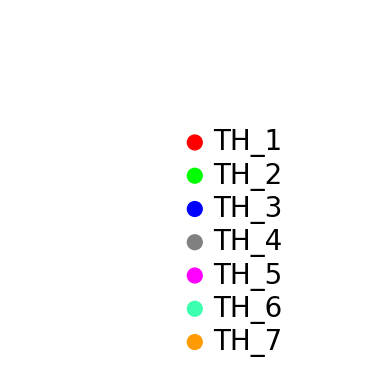

In [16]:
fig, axes = plt.subplots(1, 1)
plt.axis('off')
for i in range(0,7):
    draw_circle = plt.Circle((0.5,0.1+(6-i)*0.09), 0.02,color = (color[i][0]/255.0,color[i][1]/255.0,color[i][2]/255.0))
    plt.text(0.55,0.08+(6-i)*0.09, 'TH_'+str(i+1), fontsize=20)
    axes.set_aspect(1)
    axes.add_artist(draw_circle)
plt.savefig('../resource/svg/clusterbar.pdf',format='pdf')
plt.draw()

25
29
15
9
33
24
48
1.0003066651465846


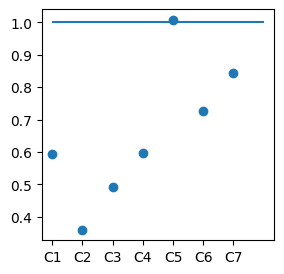

In [20]:
import random
fig,ax = plt.subplots(figsize=(3,3))
somadist=[]
allsomas=None
for i in range(np.max(cluster)):
	columns = df.columns[cluster==(i+1)]
	print(len(columns))
	neuronsomas = []
	for j in range(len(columns)):
		neuron={}
		neuron['sampleid']=columns[j][0:6]
		neuron['name']=columns[j][6:]
		property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
		neuronsomas.append( property['somapoint'] )
	somas = np.array(neuronsomas)
	if allsomas is None:
		allsomas = somas
	else:
		allsomas= np.vstack([allsomas,somas])
	sum=0
	for neuronsoma1 in somas:
		for neuronsoma2 in somas:
			dist = np.sqrt(np.sum(np.square(neuronsoma1 - neuronsoma2)))
			# print(dist,len(somas))
			sum+=dist/1000
	somadist.append(sum/len(somas)/len(somas))

#get 10 random soma points
randomSomas=[]
averageDist=[]
times=10
for j in range(times):
	for i in range(10):
		randomindex=int(random.random()*len(allsomas))
		# print(randomindex)
		randomSomas.append(allsomas[randomindex])
	sum=0
	for neuronsoma1 in randomSomas:
		for neuronsoma2 in randomSomas:
			dist = np.sqrt(np.sum(np.square(neuronsoma1 - neuronsoma2)))
			# print(dist,len(somas))
			sum+=dist/1000
	averageDist.append(sum/len(randomSomas)/len(randomSomas))

print(np.array(averageDist).mean())
plt.scatter( range(1,np.max(cluster)+1),somadist)
label=[]
for i in range(1,np.max(cluster)+1):
	label.append('C'+str(i))
plt.xticks(range(1,np.max(cluster)+1),label)
plt.hlines(y=np.array(averageDist).mean(),xmin=1,xmax=8)

[7565.1675     3782.143125   3772.50765625]
[7646.4141972  3940.27262931 3526.24959591]
[7753.58880208 3967.3734375  3792.84869792]
[6845.05251736 4054.21657986 5697.09722222]
[7378.58487216 4163.24124053 5061.94625947]
[7424.2405599  3879.69970703 4440.4625651 ]
[7071.92382812 4028.2101237  4647.17773438]
[7376.5678791  3981.82445355 4379.3464182 ]
[0.0, 0.0, 0.2, 0.48, 0.76, 0.88, 0.96, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.2413793103448276, 0.7241379310344828, 0.8620689655172413, 0.8620689655172413, 0.9310344827586207, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.2, 0.6666666666666666, 0.9333333333333333, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.0, 0.3333333333333333, 0.7777777777777778, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.030303030303030304, 0.15151515151515152, 0.24242424242424243, 0.3939393939393939, 0.6060606060606061, 0.6666666666666666, 0.9090909090909091, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
[0.0, 0.0, 0.1666666

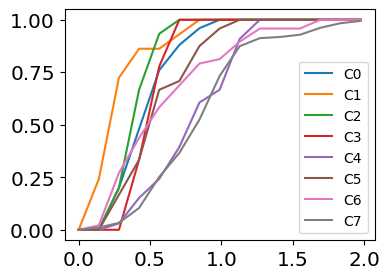

In [60]:
import random
fig,ax = plt.subplots(figsize=(4,3))
somadists=[]
maxdist=0
def dist2center(columns):
    maxdist=0
    allsomas=None
    somadist=[]
    neuronsomas = []
    for j in range(len(columns)):
        neuron={}
        neuron['sampleid']=columns[j][0:6]
        neuron['name']=columns[j][6:]
        property = iondata.getNeuronPropertyByID(neuron['sampleid'], neuron['name'])
        neuronsomas.append( property['somapoint'] )
    somas = np.array(neuronsomas)
    if allsomas is None:
        allsomas = somas
    else:
        allsomas= np.vstack([allsomas,somas])
    sum=0
    averagesoma = somas.mean(0)
    print(averagesoma)
    for neuronsoma1 in somas:
        dist = np.sqrt(np.sum(np.square(neuronsoma1 - averagesoma)))/1000
        if maxdist<dist :
            maxdist=dist

        somadist.append(dist)
    somadist.sort()
    return somadist,maxdist
for i in range(np.max(cluster)):
    columns = df.columns[cluster==(i+1)]
    somadist ,maxdist0= dist2center(columns)
    if maxdist<maxdist0:
        maxdist = maxdist0
    somadists.append(somadist)

somadist ,maxdist0= dist2center(df.columns)
somadists.append(somadist)
if maxdist<maxdist0:
    maxdist = maxdist0

x= np.linspace(0,maxdist,num = 15)

for j in range(len(somadists)):
    somadist = somadists[j]
    y=[]
    for i in x:
        count=(somadist<i)
        # print(count)
        y.append(np.sum(count)/len(somadist))
    print(y)
    p = np.poly1d(np.polyfit(x, y, 4))
    t = np.linspace(0, maxdist, 15)
    if j==8:
        plt.plot(x, y, '-.',label ='Random')
    else:
        plt.plot(x, y, '-',label ='C'+str(j))
    # plt.show()
    # break
plt.xticks(np.linspace(0,2,num = 5),fontsize='x-large')
plt.yticks(np.linspace(0,1,num = 5),fontsize='x-large')

plt.legend()

In [33]:
import Visual as nv

neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setBackgroundColor((1.0,1.00,1.0,1.0))
# neuronvis.addRegion('TH')
# neuronvis.clear(root=True,neurons=True,regions=False)
clustertemp = cluster
for i in range(np.max(clustertemp)):
    columns = df.columns[clustertemp==(i+1)]
    neurons = []
    
    for j in range(len(columns)):
        neuron={}

        neuron['sampleid']=columns[j][0:6]
        neuron['name']=columns[j][6:]
        neurons.append(neuron)
        
        neuronvis.addNeuronByID(neuron['sampleid'], neuron['name'],color=[color[i][0]/255,color[i][1]/255,color[i][2]/255],mirrorToRight=True,dendriteHide=False,axonHide=False)
        # break
    print(i,len(neurons),color[i])
    neuronvis.render.setView('left')
    # neuronvis.render.setLookAt(eye=(-5000.,0.0,0),center=(0,0,0),up=(0,-1,0))
    # neuronvis.render.setPointSize(200)
    neuronvis.render.savepng('../resource/thsample/clusterLeft'+str(i)+'.png')
    neuronvis.clear()
    # break
neuronvis.render.closeWindow()
    

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/080.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/068.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/069.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/073.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/074.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/077.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/078.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/079.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210726/086.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/031.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/211986/056.swc
exist  d:\project\python\neuron-

KeyboardInterrupt: 

In [34]:
neuronvis = nv.neuronVis(renderModel=0)
neuronvis.render.setBackgroundColor((1.0,1.00,1.0,1.0))
neuronvis.addRegion('SSs',color=[0.5,0.5,0.5])
neurons=[{'sampleid':'210727','name':'031.swc','cluster':'1'},
{'sampleid':'210662','name':'066.swc','cluster':'2'},
{'sampleid':'210661','name':'166.swc','cluster':'3'},
{'sampleid':'210726','name':'061.swc','cluster':'6'},
{'sampleid':'210661','name':'042.swc','cluster':'8'}]

for neuron in neurons:

    neuronvis.addNeuronByID(neuron['sampleid'], neuron['name'],color=[1,0,0],mirrorToRight=True,dendriteHide=False,axonHide=False)

    neuronvis.render.setView('posterior')
    neuronvis.render.savepng('../resource/thsample/clusterSSsPosterior'+neuron['cluster']+'.png')
    neuronvis.clear(regions=False)
# break
neuronvis.render.closeWindow()
# neuronvis.render.run()

specified material (mtl1)  not loaded!


exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210727/031.swc
exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210662/066.swc


KeyboardInterrupt: 

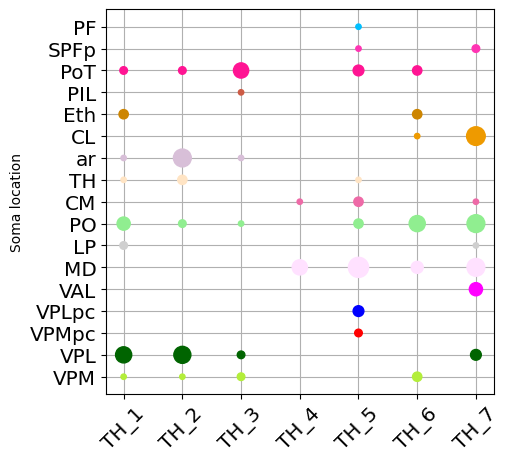

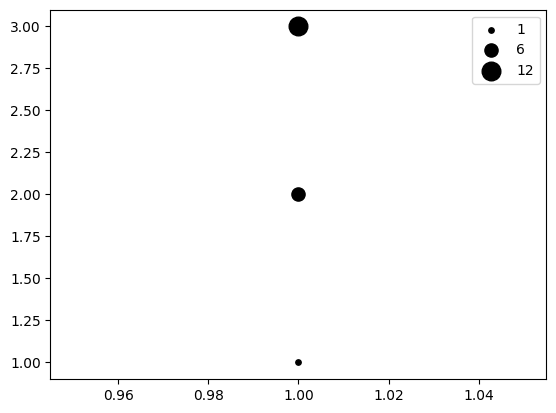

In [24]:
clustertemp = cluster
neurons = []
for i in range(np.max(clustertemp)):
    columns = df.columns[clustertemp==(i+1)]
    
    for j in range(len(columns)):
        neuron={}
        neuron['sampleid']=columns[j][0:6]
        neuron['name']=columns[j][6:]
        prop = iondata.getNeuronPropertyByID(neuron['sampleid'],neuron['name'])
        neuron['soma']=prop['somaregion']
        neuron['cluster']=i+1
        neuron['num']=1
        neurons.append(neuron)
regionclusterdf = pd.DataFrame(neurons)
# regionclusterdf.loc[regionclusterdf['cluster']==1]
testa= regionclusterdf.groupby(['soma','cluster'])['num'].sum()
testb=[]
sizep=15

for region in source_regions_sort_index:
    test={}
    test['region']=region
    for i in range(np.max(clustertemp)):
        test[i+1]=0
    if region in testa:
        for i in testa[region].keys():
            if testa[region][i]>=0:
                test[i]=testa[region][i]*sizep
            # print(region,i)
        testb.append(test)
    pass
dataframeb = pd.DataFrame(testb)
regions = dataframeb['region'].to_list()

regionnum = len(dataframeb[1].to_list())
fig,ax = plt.subplots(figsize=(5,5))
plt.grid(True)

for k in range(np.max(clustertemp)):
    # print(k)

    regioncolors = []
    for j in range(regionnum):
        index= source_regions_sort_index.index(regions[j])
        # print(index)
        regioncolor = source_regions_color[index]
        regioncolor = rgbToHex(regioncolor[0],regioncolor[1],regioncolor[2])
        regioncolors.append(regioncolor)
    
    plt.scatter(np.ones(regionnum)*(k+1),range(regionnum),  s=dataframeb[k+1].to_list(),c=regioncolors,zorder=2)


plt.yticks(range(regionnum),dataframeb['region'].to_list(),fontsize='x-large')
label=[]
for i in range(1,np.max(clustertemp)+1):
    label.append('TH_'+str(i))
plt.xticks(range(1,np.max(clustertemp)+1),label,fontsize='x-large',rotation=45)
plt.ylabel('Soma location')

plt.savefig('../resource/svg/clustersoma.pdf',format='pdf')
plt.show()
s1= plt.scatter(1,1,s=1*sizep,zorder=2,c='black')
s2= plt.scatter(1,2,s=6*sizep,zorder=2,c='black')
s3= plt.scatter(1,3,s=12*sizep,zorder=2,c='black')
plt.legend((s1,s2,s3),('1','6','12') ,loc = 'best')
plt.savefig('../resource/svg/clustersomalagend.pdf',format='pdf')
plt.show()


In [92]:
dataframeb

,region,1,2,3,4,5,6,7
0,VPM,20,20,40,0,0,60,0
1,VPL,180,200,40,0,0,0,80
2,VPMpc,0,0,0,0,40,0,0
3,VPLpc,0,0,0,0,80,0,0
4,VAL,0,0,0,0,0,0,120
5,MD,0,0,0,160,280,100,220
6,LP,40,0,0,0,0,0,20
7,PO,120,40,20,0,60,180,220
8,CM,0,0,0,20,60,0,20
9,TH,20,60,0,0,20,0,0


In [181]:
regionclusterdf

,sampleid,name,soma,cluster,num
0,210726,080.swc,VPM,1,1
1,210726,068.swc,VPL,1,1
2,210726,069.swc,VPL,1,1
3,210726,073.swc,VPL,1,1
4,210726,074.swc,VPL,1,1
...,...,...,...,...,...
199,210661,056.swc,Eth,8,1
200,210661,059.swc,PoT,8,1
201,210662,117.swc,PoT,8,1
202,210726,110.swc,PoT,8,1


In [62]:
t11 =regionclusterdf
# print(testb)
neuronRegionCluster=None
for regiondata in testb:
    for i in range(1,np.max(clustertemp)+1):
        if regiondata[i]>0:
            regionNeuronstemp = t11[(t11['soma']==regiondata['region']) & (t11['cluster']==i) ]
            if neuronRegionCluster is None:
                neuronRegionCluster = regionNeuronstemp
            else:
                # print(regionNeuronstemp)
                neuronRegionCluster=pd.concat([neuronRegionCluster,regionNeuronstemp])
neuronRegionCluster


,sampleid,name,soma,cluster,num
0,210661,169.swc,VPM,1,1
25,210726,080.swc,VPM,2,1
54,210726,131.swc,VPM,3,1
55,210726,132.swc,VPM,3,1
111,210661,146.swc,VPM,6,1
...,...,...,...,...,...
134,210726,110.swc,PoT,6,1
109,210726,063.swc,SPFp,5,1
181,210727,045.swc,SPFp,7,1
182,210727,059.swc,SPFp,7,1


In [63]:
gb = neuronRegionCluster.groupby(['cluster'])
gb_dic = list(gb)
# print(gb_dic)
propmat0=[]
columns=[]
for i in range(len(gb_dic)):
    # print(gb_dic[i][0])
    columns.append('C'+str(gb_dic[i][0]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat0.append(np.array(propmat).mean(0))

    pass

In [ ]:
gb = neuronRegionCluster.groupby(['soma','cluster'])
gb_dic = list(gb)
propmat0=[]
columns=[]
for i in range(len(gb_dic)):
    print(gb_dic[i][0])
    columns.append(gb_dic[i][0][0]+str(gb_dic[i][0][1]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        # print(row[1],row[2])
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat0.append(np.array(propmat).sum(0))

    pass

In [27]:
mat = np.array(propmat0)
mat=mat.T
mat = np.log2(mat.T/1000+1)
mat.round()

array([[0., 1., 2., 5., 3., 0., 1., 2., 2., 3., 0., 0., 0., 2., 1., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 2., 1., 2.],
       [0., 0., 0., 1., 4., 0., 0., 3., 2., 4., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 2., 0., 0.],
       [0., 0., 0., 3., 3., 0., 3., 1., 2., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 3., 0., 0., 0., 0., 2., 1., 2.],
       [3., 1., 4., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        3., 0., 3., 1., 1., 3., 2., 5., 0., 0., 0., 1., 0., 0.],
       [0., 2., 1., 1., 2., 3., 3., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 2., 3., 3., 0., 0., 0., 2., 0., 1.],
       [0., 4., 3., 5., 4., 1., 4., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 1., 0., 0., 0., 2., 0., 2.],
       [0., 5., 4., 4., 2., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

([<matplotlib.axis.XTick at 0x2b0a08fd4c0>,
 [Text(0.5, 0, 'C1'),
  Text(1.5, 0, 'C2'),
  Text(2.5, 0, 'C3'),
  Text(3.5, 0, 'C4'),
  Text(4.5, 0, 'C5'),
  Text(5.5, 0, 'C6'),
  Text(6.5, 0, 'C7')])

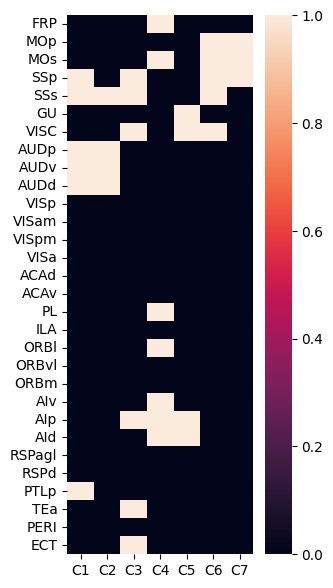

In [64]:
propmat0
mat = np.array(propmat0)
mat=mat.T
mat = np.log2(mat/1000+1)
th=2
mat[mat<th]=0
mat[mat>th]=1
fig,ax = plt.subplots(figsize=(3,7))

sns.heatmap(mat)
plt.yticks([index+0.5 for index in range(len(target_regions))],target_regions,rotation = 0)
plt.xticks([index+0.5 for index in range(len(columns))],columns,rotation = 0)


In [65]:
gb = neuronRegionCluster.groupby(['cluster'])
gb_dic = list(gb)
# print(gb_dic)
propmat2=[]
columns=[]
count=0
for i in range(len(gb_dic)):
    # print(gb_dic[i][0])
    columns.append('C'+str(gb_dic[i][0]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():

        property = iondata.getNeuronPropertyByID(row[1],row[2])
        brproperty=BR.RegionProperty(copy.deepcopy(br))
        brproperty.setProperty(property['projectregion'])
        regionsum = brproperty.getSumProperty('STR')
        if regionsum>15000:
            count+=1
print(count)

64


In [218]:
target_regions

['FRP',
 'MOp',
 'MOs',
 'SSp',
 'SSs',
 'GU',
 'VISC',
 'AUDp',
 'AUDv',
 'AUDd',
 'VISp',
 'VISam',
 'VISpm',
 'VISa',
 'ACAd',
 'ACAv',
 'PL',
 'ILA',
 'ORBl',
 'ORBvl',
 'ORBm',
 'AIv',
 'AIp',
 'AId',
 'RSPagl',
 'RSPd',
 'PTLp',
 'TEa',
 'PERI',
 'ECT',
 'STRd',
 'STRv',
 'STRd',
 'STRv',
 'STRd',
 'STRv',
 'STRd',
 'STRv',
 'STRd',
 'STRv',
 'STRd',
 'STRv',
 'STRd',
 'STRv']

In [75]:

import numpy as np
import matplotlib.pyplot as plt
import time
# target_regions0 = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
# 'RSPagl','RSPd','PTLp','TEa','PERI','ECT','STRd','STRv']
target_regions0= ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT',
'STRd','STRv','LSX','sAMY','MB','HB','TH','HY','OLF','HPF','CTXsp','PAL','CB']
gb = neuronRegionCluster.groupby(['cluster'])
gb_dic = list(gb)
# print(gb_dic)
propmat2=[]
columns=[]
for i in range(len(gb_dic)):
    # print(gb_dic[i][0])
    columns.append('C'+str(gb_dic[i][0]))
    propmat=[]
    for row in gb_dic[i][1].itertuples():
        if 1:
            property = iondata.getNeuronPropertyByID(row[1],row[2])
            brproperty=BR.RegionProperty(copy.deepcopy(br))
            brpropertyLeft=BR.RegionProperty(copy.deepcopy(br))
            brpropertyRight=BR.RegionProperty(copy.deepcopy(br))
            brproperty.setProperty(property['projectregion'])
            brpropertyLeft.setProperty(property['projectleftregion'])
            brpropertyRight.setProperty(property['projectrightregion'])
            prop=[]
            for targetRegion in target_regions0:
                regionsum = brproperty.getSumProperty(targetRegion)
                regionleft = brpropertyLeft.getSumProperty(targetRegion)
                regionright = brpropertyRight.getSumProperty(targetRegion)
                ipsi=0
                contra=0
                if property['somapoint'][2]<5700:
                    ipsi=regionleft
                    contra=regionright
                else:
                    ipsi=regionright
                    contra=regionleft
                prop.append(ipsi)
            if np.array(prop).sum()>10:
                propmat.append(prop)
    propmat2.append(propmat)

    pass
# print(propmat2)

# positions=[1,2,4,7]
# data=[
#     np.random.normal(1,5,10).tolist(),
#     np.random.normal(20,5,100).tolist(),
#     np.random.normal(30,5,100).tolist(),
#     np.random.normal(40,5,100).tolist(),
# ]

# print(len(data))

# fig,ax=plt.subplots()

# ax.violinplot(data,positions,showmeans=True,showmedians=True)


In [198]:
len(propmat2)

7

43 ['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT', 'STRd', 'STRv', 'LSX', 'sAMY', 'MB', 'HB', 'TH', 'HY', 'OLF', 'HPF', 'CTXsp', 'PAL', 'CB']
[3715.31635984, 4217.199348172414, 4297.828977466666, 34933.50070522222, 32476.843785060606, 9877.550626083334, 41960.122426395836]
56
183
[0.0, 0.0, 0.0, 6713.977309555556, 5059.326711575757, 172.95473066666662, 2284.9440272291667]
8
183


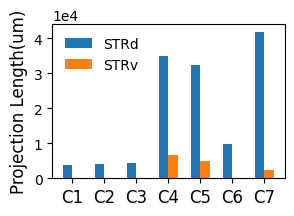

In [76]:
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.text(rect.get_x()+rect.get_width()/2.-0.2, 1.03*height, '%s' % float(height))

# print((propmat2[0]))

print(len(target_regions0),target_regions0)
positions=range(1,9)
fig,ax=plt.subplots(figsize=(3,2))
# plt.subplots_adjust(left=None,bottom=None,right=None,top=None,wspace=0,hspace=0)
i=0
j=-1
bar_width=0.3
for region in target_regions0:
    data=[]
    datacount=[]
    dataall=[]
    for c in range(len(propmat2)):
        # print(len(propmat2[c]))
        proparray2 = np.array(propmat2[c])# print(propmat2[c])
        proparray2 = proparray2.T
        p = proparray2[i]>15000
        datacount.append(p.sum())
        dataall.append(len(p))
        p = p.sum()/len(p)
        # data.append(p) #percent
        data.append(np.average(proparray2[i]))   #average
    
    if region=='STRd' or region=='STRv' :
        print(data)
        print(np.array(datacount).sum())
        print(np.array(dataall).sum())
        # print(np.array(range(1,9))+bar_width*i-9.15)
        plt.bar(np.array(range(1,len(propmat2)+1))+bar_width*i-9.15,data,width = bar_width,label=region)
    i+=1
plt.xticks([1,2,3,4,5,6,7],['C1','C2','C3','C4','C5','C6','C7'],fontsize=12)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0,0))
# plt.xlabel('Cluster',fontsize=12)
plt.ylabel('Projection Length(um)',fontsize=12)
from matplotlib import ticker
# plt.gca().yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=1))
plt.legend(edgecolor='w')
plt.savefig('../resource/svg/strProjectionLength.pdf',format='pdf',bbox_inches = 'tight')


['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT', 'STRd', 'STRv', 'LSX', 'sAMY', 'MB', 'HB', 'TH', 'HY', 'OLF', 'HPF', 'CTXsp', 'PAL', 'CB']
[array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0.]), array([   0.      ,    0.      ,    0.      ,    0.      ,    0.      ,
          0.      ,  354.628403,    0.      ,    0.      ,   19.314318,
          0.      ,    0.      ,    0.      ,    0.      ,  380.234314,
          0.      ,    0.      ,    0.      ,    0.      ,    0.      ,
          0.      , 4161.943878, 6717.096223,    0.      ,    0.      ]), array([    0.      ,     0.      ,     0.      ,     0.      ,
           0.      ,     0.      ,     0.      ,     0.      ,
           0.      ,     0.      ,     0.      ,     0.      ,
          

ValueError: List of violinplot statistics and `positions` values must have the same length

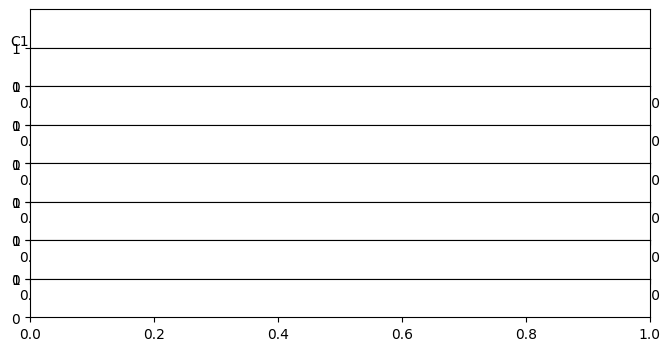

In [77]:
# import seaborn as sns
# print((propmat2[0]))
print(target_regions)
positions=range(1,len(target_regions)+1)
fig,ax=plt.subplots(8,1,figsize=(8,4))
plt.subplots_adjust(left=None,bottom=None,right=None,top=None,wspace=0,hspace=0)
j=-1
cllabel=['C1','C2','C3','C4','C5','C6','C7','C8']
for c in range(len(propmat2)):
    data=[]
    i=0

    for region in target_regions:
        # print(len(propmat2[c]))
        if region=='LSX' or region=='HB' or region=='CB':
            continue
        proparray2 = np.array(propmat2[c])# print(propmat2[c])
        proparray2 = proparray2.T
        data.append(proparray2[i])
        i+=1
    j+=1
    ax[j].set_yticks([])
    ax[j].set_xticks([])
    ax[j].set_ylabel(cllabel[j],rotation=0,y=0)
    # ax[i].axis('off')
    print(data)
    part= ax[j].violinplot(data,positions,showextrema = False,showmeans=False)
    # q1,me,q3 = np.percentile(np.array(data),[25,50,75],axis=1)
    me = [np.median(d) for d in data]
    ind = np.arange(1,len(target_regions)+1)
    # # print(data)
    ax[j].scatter(ind,me,marker="o",color="k",s=1,zorder=3)
    for pc in part["bodies"]:
        pc.set_facecolor("orange")
        pc.set_edgecolor("black")
        pc.set_alpha(1)
        pc.set_linestyle("-")

ax[j].set_xticks(positions)
ax[j].set_xticklabels(target_regions,rotation = 90)

# ax[j].set_xticklabels(['C1','C2','C3','C4','C5','C6','C7','C8'])
plt.savefig('../resource/svg/violinplot.pdf',format='pdf')

['FRP', 'MOp', 'MOs', 'SSp', 'SSs', 'GU', 'VISC', 'AUDp', 'AUDv', 'AUDd', 'VISp', 'VISam', 'VISpm', 'VISa', 'ACAd', 'ACAv', 'PL', 'ILA', 'ORBl', 'ORBvl', 'ORBm', 'AIv', 'AIp', 'AId', 'RSPagl', 'RSPd', 'PTLp', 'TEa', 'PERI', 'ECT', 'STRd', 'STRv', 'LSX', 'sAMY', 'MB', 'HB', 'TH', 'HY', 'OLF', 'HPF', 'CTXsp', 'PAL', 'CB']


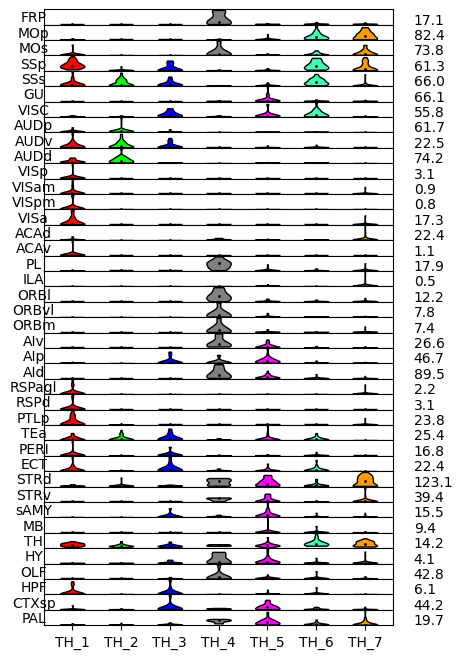

In [94]:
# import seaborn as sns
target_regions = ['FRP','MOp','MOs','SSp','SSs','GU','VISC','AUDp','AUDv','AUDd','VISp','VISam','VISpm','VISa','ACAd','ACAv','PL','ILA','ORBl','ORBvl','ORBm','AIv','AIp','AId',
'RSPagl','RSPd','PTLp','TEa','PERI','ECT',
'STRd','STRv','LSX','sAMY','MB','HB','TH','HY','OLF','HPF','CTXsp','PAL','CB']
# print((propmat2[0]))
print(target_regions)
positions=range(1,np.max(clustertemp)+1)
fig,ax=plt.subplots(len(target_regions)-3,1,figsize=(4.5,8))
plt.subplots_adjust(left=None,bottom=None,right=None,top=None,wspace=0,hspace=0)
i=0
j=-1
for region in target_regions:
    data=[]

    for c in range(len(propmat2)):
        # print(len(propmat2[c]))
        proparray2 = np.array(propmat2[c])# print(propmat2[c])
        proparray2 = proparray2.T
        data.append(proparray2[i])
    i+=1
    # print(np.array(data))
    
    if region=='LSX' or region=='HB' or region=='CB':

        continue
    j+=1

    ax[j].set_yticks([])
    ax[j].set_xticks([])
    ax[j].set_ylabel(region,rotation=0,y=0)
    # ax[i].axis('off')
    part= ax[j].violinplot(data,positions,showextrema = False,showmeans=False)

    # q1,me,q3 = np.percentile(np.array(data),[25,50,75],axis=1)
    me = [np.median(d) for d in data]
    ind = np.arange(1,np.max(clustertemp)+1)
    # # print(data)
    ax[j].scatter(ind,me,marker="o",color="k",s=1,zorder=3)
    for k in  range(len(part["bodies"])):
        pc = part["bodies"][k]
        pc.set_facecolor(rgbToHex(color[k][0],color[k][1],color[k][2]))
        pc.set_edgecolor("black")
        pc.set_alpha(1)
        pc.set_linestyle("-")
    ma = np.max([np.max(d) for d in data])
    # print(j)
    ax[j].text(8,j,str(round(ma/1000,1)))

ax[j].set_xticks([1,2,3,4,5,6,7])
ax[j].set_xticklabels(['TH_1','TH_2','TH_3','TH_4','TH_5','TH_6','TH_7'])
# ax[0].tick_params(labelbottom='off',labeltop='on')
# ax[j].set_xticklabels(['C1','C2','C3','C4','C5','C6','C7','C8'])
plt.savefig('../resource/svg/violinplot.pdf',format='pdf')



In [68]:
import FlatNeuron
from skimage import draw, io
from pathlib import Path


In [146]:
import FlatNeuron
from skimage import draw, io

grid,dv0,dv1,dv2,flatenPara = FlatNeuron.getStreamLine()
img0 = io.imread(r'../resource/flatmapedgebgd.png')
singleimg = img0
for i in range(max(cluster)):
    img0[:]=0
    neurons = df.columns[cluster==(i+1)]
    for neuron in neurons:
        if Path("../resource/thsample/flatmap/"+neuron[0:-4]+'flatbgd.png').exists():
            continue
        singleimg[:]=0
        
        print(i,neuron)
        neurontree = iondata.getNeuronTreeByID(neuron[0:6], neuron[6:])
        FlatNeuron.flatneuron(neurontree,grid,dv0,dv1,dv2,flatenPara,sum=True,img=singleimg)
        io.imsave("../resource/thsample/flatmap/"+neuron[0:-4]+'flatbgd.png',singleimg)
        # img0+=singleimg
    # io.imsave("../resource/thsample/flatmap/modulecluster"+str(i)+'flatbgd.png',img0)


NameError: name 'Path' is not defined

In [196]:
img0 = io.imread(r'../resource/flatmapedgebgd.png')
for i in range(max(cluster)):
    img0[:]=0
    neurons = df.columns[cluster==(i+1)]
    print(i,(neurons))
    for neuron in neurons:
        singleimg = io.imread("../resource/thsample/flatmap/"+neuron[0:-4]+'flatbgd.png')
        img0+=singleimg
    io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


0 Index(['210661169.swc', '210726065.swc', '210726066.swc', '210726067.swc',
       '210726075.swc', '210726076.swc', '210726082.swc', '210726084.swc',
       '210726087.swc', '210726088.swc', '210661052.swc', '210661172.swc',
       '210661168.swc', '210661170.swc', '210661179.swc', '210662066.swc',
       '210662067.swc', '210662069.swc', '211986037.swc', '210727018.swc',
       '210661045.swc', '210661143.swc', '210662068.swc', '210661132.swc',
       '211986058.swc'],
      dtype='object')


D:\project\python\AppData\Local\Temp\ipykernel_33412\2176657457.py:9: UserWarning: ../resource/thsample/flatmap/modulecluster2-0flatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


1 Index(['210726080.swc', '210726068.swc', '210726069.swc', '210726073.swc',
       '210726074.swc', '210726077.swc', '210726078.swc', '210726079.swc',
       '210726086.swc', '210727031.swc', '211986056.swc', '210661046.swc',
       '210661171.swc', '210727001.swc', '210727055.swc', '211986036.swc',
       '210726070.swc', '210726071.swc', '210726072.swc', '210727002.swc',
       '210727003.swc', '210727005.swc', '210727019.swc', '210727030.swc',
       '210727032.swc', '210727033.swc', '210727056.swc', '210661176.swc',
       '210661177.swc'],
      dtype='object')


D:\project\python\AppData\Local\Temp\ipykernel_33412\2176657457.py:9: UserWarning: ../resource/thsample/flatmap/modulecluster2-1flatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


2 Index(['210726131.swc', '210726132.swc', '210726081.swc', '210726089.swc',
       '211986066.swc', '211986057.swc', '210726106.swc', '210661123.swc',
       '210661130.swc', '210661133.swc', '210661135.swc', '210661166.swc',
       '210661175.swc', '210661215.swc', '210727029.swc'],
      dtype='object')


...

D:\project\python\AppData\Local\Temp\ipykernel_33412\2176657457.py:9: UserWarning: ../resource/thsample/flatmap/modulecluster2-4flatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


5 Index(['210661146.swc', '210726062.swc', '211181072.swc', '210098013.swc',
       '210661078.swc', '211984036.swc', '211984043.swc', '211984045.swc',
       '210661042.swc', '210661043.swc', '210661044.swc', '210661058.swc',
       '210661060.swc', '210661136.swc', '210661137.swc', '210661197.swc',
       '210661208.swc', '211181071.swc', '210661054.swc', '210661056.swc',
       '210661125.swc', '210661059.swc', '210662117.swc', '210726110.swc'],
      dtype='object')


D:\project\python\AppData\Local\Temp\ipykernel_33412\2176657457.py:9: UserWarning: ../resource/thsample/flatmap/modulecluster2-5flatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


6 Index(['210661154.swc', '210726083.swc', '210726123.swc', '211181074.swc',
       '210661206.swc', '210661207.swc', '211181063.swc', '211181066.swc',
       '211181073.swc', '211986069.swc', '210098011.swc', '210098025.swc',
       '210098027.swc', '210098029.swc', '210661079.swc', '210661080.swc',
       '210661173.swc', '210662073.swc', '211181070.swc', '211984018.swc',
       '211984034.swc', '210662070.swc', '210661047.swc', '210661048.swc',
       '210661049.swc', '210661050.swc', '210661053.swc', '210661057.swc',
       '210661198.swc', '210661199.swc', '210662071.swc', '210662072.swc',
       '210662115.swc', '211984013.swc', '210661055.swc', '210661081.swc',
       '210661205.swc', '210662105.swc', '210662106.swc', '210662108.swc',
       '210662109.swc', '210662110.swc', '210662111.swc', '210662113.swc',
       '211181064.swc', '211181065.swc', '210727045.swc', '210727059.swc'],
      dtype='object')


D:\project\python\AppData\Local\Temp\ipykernel_33412\2176657457.py:9: UserWarning: ../resource/thsample/flatmap/modulecluster2-6flatbgd.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png',img0)


In [151]:
lut = pd.read_csv('../resource/LUT.csv')
lut = lut.to_numpy()

lut=lut[::-1,1:4]
# lut = lut[:,::-1]
lut

array([[  0,   0,   0],
       [  0,   0,   7],
       [  0,   0,  15],
       [  0,   0,  22],
       [  0,   0,  30],
       [  0,   0,  38],
       [  0,   0,  45],
       [  0,   0,  53],
       [  0,   0,  61],
       [  0,   0,  65],
       [  0,   0,  69],
       [  0,   0,  74],
       [  0,   0,  78],
       [  0,   0,  82],
       [  0,   0,  87],
       [  0,   0,  91],
       [  1,   0,  96],
       [  4,   0, 100],
       [  7,   0, 104],
       [ 10,   0, 108],
       [ 13,   0, 113],
       [ 16,   0, 117],
       [ 19,   0, 121],
       [ 22,   0, 125],
       [ 25,   0, 130],
       [ 28,   0, 134],
       [ 31,   0, 138],
       [ 34,   0, 143],
       [ 37,   0, 147],
       [ 40,   0, 151],
       [ 43,   0, 156],
       [ 46,   0, 160],
       [ 49,   0, 165],
       [ 52,   0, 168],
       [ 55,   0, 171],
       [ 58,   0, 175],
       [ 61,   0, 178],
       [ 64,   0, 181],
       [ 67,   0, 185],
       [ 70,   0, 188],
       [ 73,   0, 192],
       [ 76,   0

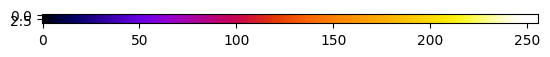

In [157]:

plt.imshow([lut,lut,lut,lut,lut])
# plt.colorbar();
plt.savefig('../resource/svg/flatmapcolorbar.pdf',format='pdf')

In [5]:
from skimage import draw, io
from skimage import filters
import numpy as np

lut = pd.read_csv('../resource/LUT.csv')
lut = lut.to_numpy()
lut=lut[:,1:4]
print(lut[0])
maxvalue=0
imgbgd = io.imread(r'../resource/flatmapedge3.png')
for i in range(7):
    clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
    print(i,np.max(clusterimg))
    if np.max(clusterimg)==0:
        continue
    if maxvalue<np.max(clusterimg):
        maxvalue=np.max(clusterimg)
for i in range(7):
    if os.path.isfile("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png'):
        clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
        img = clusterimg*255/maxvalue
        img1 = filters.gaussian(img,sigma=4)
        img1 = img1[:,:,0]
        img2 = img1.reshape([img1.shape[0]*img1.shape[1]])
        # print(region)
        img2 = img2*40
        img2=img2.astype(np.int8)
        img3 = lut[img2]
        img4 = img3.reshape([img1.shape[0],img1.shape[1],3])
        # img4[imgbgd[:,:,0]==0]=[0,0,0]
        # io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblurwithoutregion.png',img4)

[255 255 255]
0 37
1 47
2 22
3 29
4 32
5 26
6 44


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\_shared\utils.py:348: RuntimeWarning: Images with dimensions (M, N, 3) are interpreted as 2D+RGB by default. Use `multichannel=False` to interpret as 3D image with last dimension of length 3.
  return func(*args, **kwargs)


In [10]:
def f(x,y):
    #the height function
    return(1-x/2+x**5+y**3)*np.exp(-x**2-y**2)
n=256

fig,ax=plt.subplots(figsize=(15,15))
for i in range(7):
    clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
    img = clusterimg*255/maxvalue
    img1 = filters.gaussian(img,sigma=15)
    img1 = img1[::1,:,0]
    img2 = img1.reshape([img1.shape[0]*img1.shape[1]])
            # print(region)
    img2 = img2*40
    img2=img2.astype(np.int8)
    img3 = lut[img2]
    img4 = img3.reshape([img1.shape[0],img1.shape[1],3])
    x=np.linspace(0,img.shape[0],img.shape[0])
    y=np.linspace(0,img.shape[1],img.shape[0])
    X,Y = np.meshgrid(x,y) #将x,y设置为禁锢在边框中的随机点并且重新赋值X,Y
    # img4[imgbgd[:,:,0]==0]=[0,0,0]
    #use plt.contourf to filing contours
    #先设置等高图
    plt.cla()
    plt.imshow(img4)
    plt.contour(X,Y,img1, levels=[1, 3,5],colors ='black',linewidths = 5 )
    # ax = plt.subplot()
    # ax.contourf(grid_x_plot, grid_y_plot, f_plot, levels = levels, cmap=cmap2)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.margins(0, 0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.savefig('../resource/thsample/flatmap/contour'+str(i)+'.png')

d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\_shared\utils.py:348: RuntimeWarning: Images with dimensions (M, N, 3) are interpreted as 2D+RGB by default. Use `multichannel=False` to interpret as 3D image with last dimension of length 3.
  return func(*args, **kwargs)


In [87]:
from skimage import filters
lut = pd.read_csv('../resource/LUT.csv')
lut = lut.to_numpy()
lut=lut[:,1:4]
print(lut[0])
maxvalue=0
imgbgd = io.imread(r'../resource/flatmapedge3.png')
for i in range(max(cluster)):
    clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
    print(i,np.max(clusterimg))
    if np.max(clusterimg)==0:
        continue
    if maxvalue<np.max(clusterimg):
        maxvalue=np.max(clusterimg)
for i in range(max(cluster)):
    if os.path.isfile("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png'):
        clusterimg = io.imread("../resource/thsample/flatmap/modulecluster2-"+str(i)+'flatbgd.png')
        img = clusterimg*255/maxvalue
        img1 = filters.gaussian(img,sigma=4)
        img1 = img1[:,:,0]
        img2 = img1.reshape([img1.shape[0]*img1.shape[1]])
        # print(region)
        img2 = img2*40
        img2=img2.astype(np.int8)
        img3 = lut[img2]
        img4 = img3.reshape([img1.shape[0],img1.shape[1],3])
        # img4[imgbgd[:,:,0]==0]=[0,0,0]
        io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblurwithoutregion.png',img4)

[255 255 255]
0 37
1 47
2 22
3 29
4 32
5 26
6 44


d:\Program Files\anaconda3\envs\neuronVis\lib\site-packages\skimage\_shared\utils.py:348: RuntimeWarning: Images with dimensions (M, N, 3) are interpreted as 2D+RGB by default. Use `multichannel=False` to interpret as 3D image with last dimension of length 3.
  return func(*args, **kwargs)
C:\Users\wxf\AppData\Local\Temp\ipykernel_17492\4288182594.py:28: UserWarning: ../resource/thsample/flatmap/module20flatblurwithoutregion.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblurwithoutregion.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uint8 prior to saving to suppress this warning.
C:\Users\wxf\AppData\Local\Temp\ipykernel_17492\4288182594.py:28: UserWarning: ../resource/thsample/flatmap/module21flatblurwithoutregion.png is a low contrast image
  io.imsave("../resource/thsample/flatmap/module2"+str(i)+'flatblurwithoutregion.png',img4)
Lossy conversion from int64 to uint8. Range [0, 255]. Convert image to uin

165 11 [ 9  1  8  3  7  7  3  7  5  5  2  1 11  7  6  3 10  8  9  8  7  5  7  5
  7  9  2 11  2  4  9  7  2  6  9  3 10  7  1  4  9  7  3  9  6  5 11  5
 11 11  7  1  9  3  7  7  3  3  2  1  1  7  2  8  4  9  7  5  2 11  7  9
  3  9  7  5  1  2  1  2  2  7  8  3  8 11  6  9  9  5 11  9  6 10  9  6
  5  6  4  7 11  7  4  3  3  7  9  3  7  3  9  7  6  7  7  7  9  1  1  9
  1  6 10  3  7  7  1  7  2  3  7  1  4 11 11  9  7  6  7 11  3  7  8  4
 10  4  8  2 10  7  3  9  7  3 10  2  7  1  5  4  8  7  7  3  5]


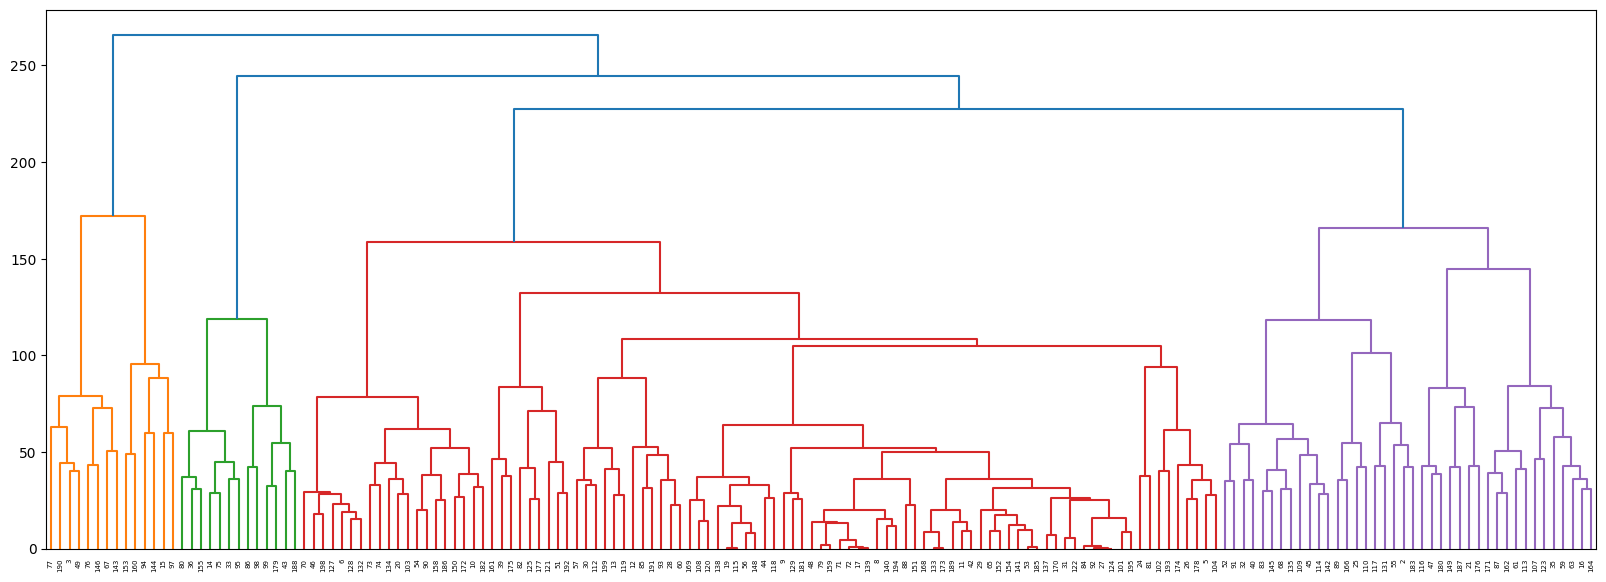

In [121]:
fig,ax = plt.subplots(figsize=(20,7))
def fclusterDF2(dataframe):
		matData =  dataframe.values[:,:].transpose()
		distance = spatial.distance.pdist(matData.astype(float))
		linkresult = linkage(distance,method='ward',metric='euclidean')
		
		cluster=fcluster(linkresult,t=3.15,criterion='inconsistent',depth=25,R=None,monocrit=None)#这个需要先计算linkage，再出结果
		dendrogram(linkresult,labels=dataframe.columns[:])
		return cluster
cluster = fclusterDF2(df.T)
print(len(cluster),np.max(cluster),cluster)



#010000


22 Rectangle(xy=(0.1, 47.4), width=0.1, height=6.6, angle=0) #F00
14 Rectangle(xy=(0.1, 43.2), width=0.1, height=4.2, angle=0) #0F0
14 Rectangle(xy=(0.1, 39), width=0.1, height=4.2, angle=0) #00F
14 Rectangle(xy=(0.1, 34.8), width=0.1, height=4.2, angle=0) #808080
11 Rectangle(xy=(0.1, 31.5), width=0.1, height=3.3, angle=0) #F0F
50 Rectangle(xy=(0.1, 16.5), width=0.1, height=15, angle=0) #3CFFAF
16 Rectangle(xy=(0.1, 11.7), width=0.1, height=4.8, angle=0) #FF9B00
20 Rectangle(xy=(0.1, 5.7), width=0.1, height=6, angle=0) #699B37
18 Rectangle(xy=(0.1, 0.3), width=0.1, height=5.4, angle=0) #9B9BCD
[49.800000000000004, 51.0, 52.2, 44.4, 45.599999999999994, 40.199999999999996, 41.39999999999999, 36.0, 37.199999999999996, 32.25000000000001, 33.45, 34.650000000000006, 23.1, 24.3, 25.5, 13.200000000000001, 14.400000000000002, 15.600000000000001, 7.8000000000000025, 9.000000000000004, 1.2000000000000002, 2.4, 3.6, 4.8] ['SSs', 'SSp', 'AUD', 'AI', 'GU', 'SSs', 'SSp', 'MOp', 'MOs', 'TEa', 'AUD', 

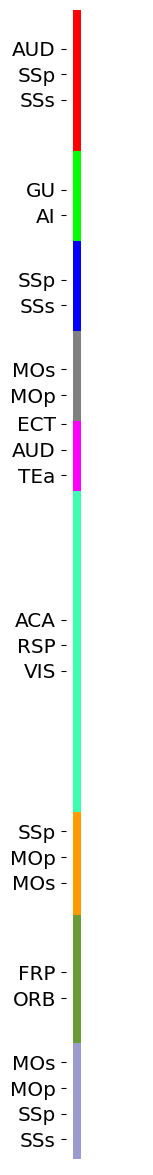

In [31]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(1,15))
ax = fig.add_subplot(111)
ax.set_ylim(0,54)
ax.set_xlim(0,1)
# ax = plt.axes()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
start=0
regionlabels=[['SSs','SSp','AUD'],['AI','GU'],['SSs','SSp'],
['MOp','MOs'],['TEa','AUD','ECT'],['VIS','RSP','ACA'],
['MOs','MOp','SSp'],['ORB','FRP'],['SSs','SSp','MOp','MOs']]
labelstemp =[]
yindex =[]
for i in range(np.max(cluster)):
    columns = df.T.columns[cluster==(i+1)]
    # print(columns)
    regionlabel = regionlabels[i]
    clustercenter = 54-0.3*len(columns)/2-start
    j=-3*int(len(regionlabel)/2)
    for label in regionlabel:
        # print(label)
        yindex.append(clustercenter+j*0.3)
        j+=4
        labelstemp.append(label)
    rect = plt.Rectangle((0.1,54-0.3*len(columns)-start),0.1,0.3*len(columns),facecolor=rgbToHex(color[i][0],color[i][1],color[i][2]))
    # rect.set_facecolor(rgbToHex(color[i][0],color[i][1],color[i][2]))
    print(len(columns),rect,rgbToHex(color[i][0],color[i][1],color[i][2]))
    start=start+0.3*len(columns)
    ax.add_patch(rect)
    pass
# rect = plt.Rectangle((0.1,4.1),0.5,0.3)
# print(rect)
# ax.add_patch(rect)
# plt.xticks([])
print(yindex,labelstemp)
plt.yticks(yindex,labelstemp,rotation = 0,fontsize='x-large')
plt.xticks([])
# plt.axis('off')

plt.show()


In [99]:
from skimage import draw, io

isomoduleflatmap = io.imread("../resource/isomoduleflatmap.png")
flatmapedge = io.imread("../resource/flatmapedge.png")
isomoduleflatmapedge = io.imread("../resource/isomoduleflatmap-1.png")
isomodule = np.zeros([isomoduleflatmap.shape[0],isomoduleflatmap.shape[1],3])+255
for i in range(np.max(cluster)):
    dfT=df.T
    columns = dfT.columns[cluster==(i+1)]
    for j in range(len(columns)):
        isomodule[isomoduleflatmap==columns[j]]=color[i]
    # print(len(columns),columns)
isomodule[isomoduleflatmapedge[:,:]==255]=[0,0,0]

isomodule[flatmapedge[:,:,1]<120]=[0,0,0]
io.imsave("../resource/isomodule2.png",isomodule)

Lossy conversion from float64 to uint8. Range [0.0, 255.0]. Convert image to uint8 prior to saving to suppress this warning.


In [96]:
flatmapedge.shape

(1500, 1500, 4)

In [ ]:
import Flatmap
import BoundLaplace
import nrrd
import numpy as np

layer = [120, 400, 570, 850, 1200] # in micron, SS results employing ../neuronVis/LayerThickness.py
layerName = ['L1','L2/3','L4','L5','L6']
iondata = IONData.IONData()

flatenPara=Flatmap.createSurfaceGraph()

res,gridpath = iondata.getFileFromServer("boundlaplace20.nrrd")
grid,header = nrrd.read(gridpath)

resRelaxation,RelaxationPath=iondata.getFileFromServer('boundlaplaceout20.nrrd')
relaxation,relaxationheader = nrrd.read(RelaxationPath)

resdv0,dv0Path=iondata.getFileFromServer('dv0.nrrd')
dv0,dv0header = nrrd.read(dv0Path)
resdv1,dv1Path=iondata.getFileFromServer('dv1.nrrd')
dv1,dv1header = nrrd.read(dv1Path)
resdv2,dv2Path=iondata.getFileFromServer('dv2.nrrd')
dv2,dv2header = nrrd.read(dv2Path)

dv0=dv0.astype(np.float32)/1000-1
dv1=dv1.astype(np.float32)/1000-1
dv2=dv2.astype(np.float32)/1000-1

In [ ]:
from fileinput import filename
import Scene

source_regions_VPMVPL = ['VPM','VPL','VPMpc','VPLpc']

list=[]
for region in source_regions_VPMVPL:
    list+=(regionNeurons[region])
Scene.createScene(list,filename='../resource/TH_VPMVPL.nv')

source_regions_other = ['LGd','MG','VAL','AM','SMT','MD','LP','PO','LD','VM','RE','CM','TH','ar','CL','Eth','PIL','PoT','SPFp','ZI']

list=[]
for region in source_regions_other:
    list+=(regionNeurons[region])
Scene.createScene(list,filename='../resource/TH_OTHER.nv')

In [ ]:

import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
%matplotlib inline
import FlatNeuron,Flatmap

grid,dv0,dv1,dv2,flatenPara = FlatNeuron.getStreamLine()



In [ ]:
neuronT = iondata.getNeuronTreeByID(regionNeurons['VPM'][1]['sampleid'], regionNeurons['VPM'][1]['name'])

FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)

In [ ]:
regionNeurons['VPM']

In [ ]:
neuronT = iondata.getNeuronTreeByID(regionNeurons['VPM'][2]['sampleid'], regionNeurons['VPM'][2]['name'])

FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)

In [ ]:
neuronT = iondata.getNeuronTreeByID('210098','004.swc')
FlatNeuron.flatneuron(neuronT,grid,dv0,dv1,dv2,flatenPara)
FlatNeuron.plt.savefig('../resource/thsample/flatmap/test.png', format='png', dpi=300)

In [11]:
import nrrd
moduleiso,header = nrrd.read("../resource/moduleiso.nrrd")
moduleiso.shape

(660, 400, 570)

In [7]:

import json
import matplotlib.pyplot as plt
import numpy as np
import IONData 
import SwcLoader
import matplotlib.image as img

iondata =IONData.IONData()
swc = iondata.getNeuronByID('211984', '045.swc')

neuron = SwcLoader.NeuronTree()
neuron.readSWC(swc)
plt.figure(figsize=(24, 24))
axes0 = plt.subplot(111)
plt.axis('off')
axes0.set_xlim(0, 10000)
axes0.set_ylim(0, 10000)
# plt.Circle((neuron.root.z, neuron.root.y), 300)
# im =img.imread('../resource/nrrd/MAX_210660ch00ds_reg.png')
# plt.imshow(im,cmap=plt.cm.gray)
for edge in neuron.edges:
    x=[]
    y=[]
    for p in edge.data:
        x.append(10000-p.z)
        y.append(10000-p.y)
    plt.plot(x, y,color='#FF88aa')
# plt.figure(facecolor='gainsboro')
# plt.plot(10000-neuron.root.z,10000- neuron.root.y,'ob')


plt.savefig(fname="../resource/svg/211984045.svg",format="svg")
plt.show()

exist  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/211984/045.swc


D:\project\python\AppData\Local\Temp\ipykernel_15040\1339227500.py:33: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


In [9]:
import Scene
neuronlist=[]
for i in range(7):
    neuronlist.extend(Scene.scene2List('../resource/thsample/matrix/thisocluster-'+str(i+1)+'.nv'))
print(neuronlist)
for neuron in neuronlist:
    del neuron['color']
print(neuronlist)
Scene.createScene(neuronlist,'../resource/thsample/allthneuron.nv')

[{'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '169.swc', 'sampleid': '210661', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '065.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '066.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '067.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '075.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '076.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '082.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '084.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '087.swc', 'sampleid': '210726', 'soma': 'PF'}, {'color': {'r': '255', 'g': '0', 'b': '0'}, 'name': '088.swc', 'sampleid': '210726', 'soma': 'PF'},

write  d:\project\python\neuron-vis\figures/../neuronVis/../resource/swc/210661/162.swc


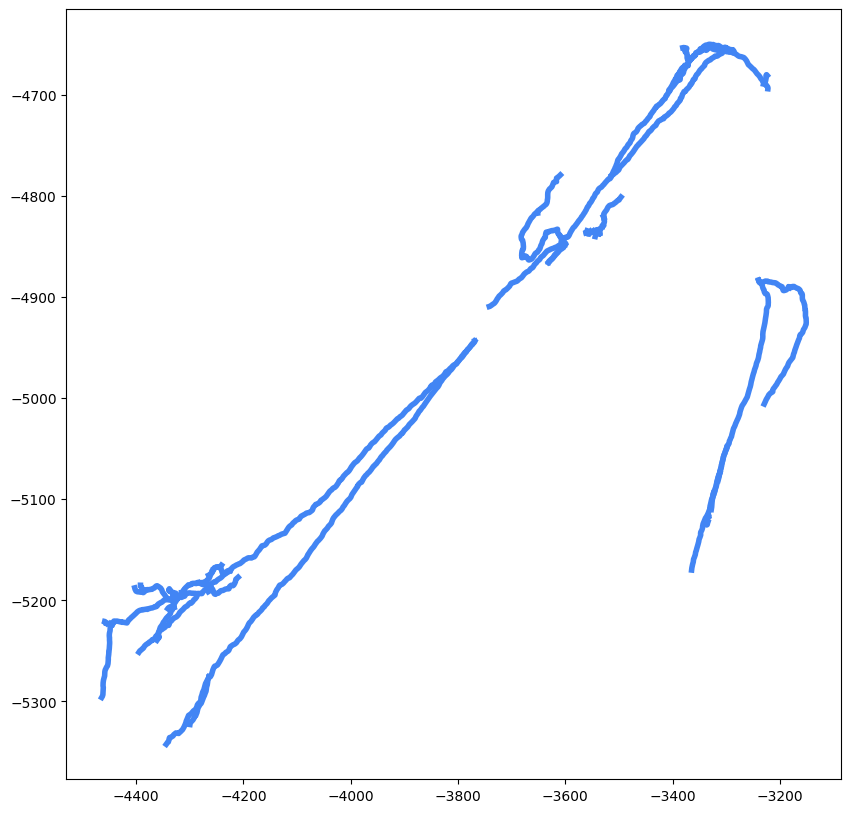

In [100]:
data = IONData.IONData()
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
color = np.array(('66','133','244')).astype(float)/255
for edge in data.getNeuronTreeByID('210661','162.swc').getDendrite():
    X = []
    for k in edge.data[::1]:
        X.append(k.xyz)
    X = np.array(X)
    ax.plot(-X[:,2],-X[:,1],linewidth=4,color=color)
plt.show()